# 01. 探索的データ分析 (EDA) — 2026-03-08

## リクルート飲食店来客数予測コンペティション

**目的**: データ品質、時系列パターン、祝日効果を深掘りし、特徴量エンジニアリングとバリデーション戦略の方針を定める。

### 分析セクション
1. データ読み込みとプロファイリング
2. 欠損日と店舗ライフサイクル分析
3. データ開始日とカバレッジ分析
4. 目的変数の分布と外れ値
5. 時系列パターン（曜日・月・年）
6. 自己相関とSTL分解
7. 祝日・特別期間分析（生データ、店舗別、移動平均）
8. 店舗・ジャンル・地域分析
9. 予約データ分析
10. 訓練/テストデータの分布シフト
11. バリデーション戦略設計
12. EDAまとめと特徴量候補
13. 中間データ保存（ジャンル別特徴量有効性サマリ + pickle出力）

**方法論参考**: `../../../../methodology.md`

---
## 1. データ読み込みとプロファイリング

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 日本語フォント設定
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False

# パス設定（説明用資料/ から2階層上がcompetitionルート）
INPUT_DIR = Path('../../input')

# 全テーブルの読み込み
air_visit = pd.read_csv(INPUT_DIR / 'air_visit_data.csv', parse_dates=['visit_date'])
air_reserve = pd.read_csv(INPUT_DIR / 'air_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
air_store = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
hpg_reserve = pd.read_csv(INPUT_DIR / 'hpg_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
hpg_store = pd.read_csv(INPUT_DIR / 'hpg_store_info.csv')
store_relation = pd.read_csv(INPUT_DIR / 'store_id_relation.csv')
date_info = pd.read_csv(INPUT_DIR / 'date_info.csv', parse_dates=['calendar_date'])
sample_sub = pd.read_csv(INPUT_DIR / 'sample_submission.csv')

print('=== データプロファイリング ===')
tables = {
    'air_visit': air_visit,
    'air_reserve': air_reserve,
    'air_store': air_store,
    'hpg_reserve': hpg_reserve,
    'hpg_store': hpg_store,
    'store_relation': store_relation,
    'date_info': date_info,
    'sample_submission': sample_sub,
}

for name, df in tables.items():
    print(f'\n{name}: {df.shape[0]:,} rows × {df.shape[1]} cols | Memory: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB')
    print(f'  Columns: {list(df.columns)}')
    print(f'  Dtypes: {dict(df.dtypes)}')

# 結合キーのカバレッジ
print('\n=== 結合キーカバレッジ ===')
air_visit_stores = set(air_visit['air_store_id'].unique())
air_store_stores = set(air_store['air_store_id'].unique())
air_reserve_stores = set(air_reserve['air_store_id'].unique())
print(f'air_visit stores: {len(air_visit_stores)}')
print(f'air_store stores: {len(air_store_stores)}')
print(f'air_reserve stores: {len(air_reserve_stores)}')
print(f'visit ∩ store: {len(air_visit_stores & air_store_stores)} ({len(air_visit_stores & air_store_stores)/len(air_visit_stores)*100:.0f}%)')
print(f'visit ∩ reserve: {len(air_visit_stores & air_reserve_stores)} ({len(air_visit_stores & air_reserve_stores)/len(air_visit_stores)*100:.0f}%)')
print(f'HPG linked to Air: {store_relation.shape[0]}')

=== データプロファイリング ===

air_visit: 252,108 rows × 3 cols | Memory: 20.4 MB
  Columns: ['air_store_id', 'visit_date', 'visitors']
  Dtypes: {'air_store_id': dtype('O'), 'visit_date': dtype('<M8[ns]'), 'visitors': dtype('int64')}

air_reserve: 92,378 rows × 4 cols | Memory: 8.2 MB
  Columns: ['air_store_id', 'visit_datetime', 'reserve_datetime', 'reserve_visitors']
  Dtypes: {'air_store_id': dtype('O'), 'visit_datetime': dtype('<M8[ns]'), 'reserve_datetime': dtype('<M8[ns]'), 'reserve_visitors': dtype('int64')}

air_store: 829 rows × 5 cols | Memory: 0.2 MB
  Columns: ['air_store_id', 'air_genre_name', 'air_area_name', 'latitude', 'longitude']
  Dtypes: {'air_store_id': dtype('O'), 'air_genre_name': dtype('O'), 'air_area_name': dtype('O'), 'latitude': dtype('float64'), 'longitude': dtype('float64')}

hpg_reserve: 2,000,320 rows × 4 cols | Memory: 177.4 MB
  Columns: ['hpg_store_id', 'visit_datetime', 'reserve_datetime', 'reserve_visitors']
  Dtypes: {'hpg_store_id': dtype('O'), 'visit_datet

In [2]:
# Missing values and duplicates check
print('=== Missing Values ===')
for name, df in [('air_visit', air_visit), ('air_store', air_store),
                  ('air_reserve', air_reserve), ('hpg_reserve', hpg_reserve),
                  ('hpg_store', hpg_store), ('date_info', date_info)]:
    missing = df.isnull().sum()
    if missing.any():
        print(f'\n{name}:')
        print(missing[missing > 0])
    else:
        print(f'  {name}: No missing values')

print('\n=== Duplicate Rows ===')
for name, df in [('air_visit', air_visit), ('air_store', air_store),
                  ('air_reserve', air_reserve), ('date_info', date_info)]:
    n_dup = df.duplicated().sum()
    print(f'  {name}: {n_dup} duplicates')

# Check primary key uniqueness
print('\n=== Primary Key Uniqueness ===')
n_unique = air_visit.groupby(['air_store_id', 'visit_date']).size()
print(f'  air_visit (store_id, visit_date): max count = {n_unique.max()} (should be 1)')

=== Missing Values ===
  air_visit: No missing values
  air_store: No missing values
  air_reserve: No missing values
  hpg_reserve: No missing values
  hpg_store: No missing values
  date_info: No missing values

=== Duplicate Rows ===
  air_visit: 0 duplicates
  air_store: 0 duplicates
  air_reserve: 2770 duplicates
  date_info: 0 duplicates

=== Primary Key Uniqueness ===
  air_visit (store_id, visit_date): max count = 1 (should be 1)


---
## 2. 欠損日と店舗ライフサイクル分析

欠損レコードの考えられる原因：
- **A. 定休日**: 毎週特定の曜日に営業しない（例：月曜定休）
- **B. 臨時休業**: 不定期な休業（改装、災害など）
- **C. 来客数ゼロ**: 記録されない可能性あり
- **D. データ記録漏れ**: システム障害やデータ未入力
- **E. 開業前/閉店後**: 店舗のライフサイクル外の期間

In [3]:
# Build a full calendar grid: store × date
all_dates = pd.date_range(air_visit['visit_date'].min(), air_visit['visit_date'].max(), freq='D')
all_stores = air_visit['air_store_id'].unique()

# Per-store first/last observation
store_lifecycle = air_visit.groupby('air_store_id')['visit_date'].agg(
    first_date='min', last_date='max', n_records='count'
)
store_lifecycle['expected_days'] = (store_lifecycle['last_date'] - store_lifecycle['first_date']).dt.days + 1
store_lifecycle['missing_days'] = store_lifecycle['expected_days'] - store_lifecycle['n_records']
store_lifecycle['missing_rate'] = store_lifecycle['missing_days'] / store_lifecycle['expected_days']

print('=== Store Lifecycle Summary ===')
print(f'Total stores: {len(store_lifecycle)}')
print(f'\nFirst observation date distribution:')
print(store_lifecycle['first_date'].describe())
print(f'\nMissing days per store:')
print(store_lifecycle['missing_days'].describe())
print(f'\nStores with >20% missing days: {(store_lifecycle["missing_rate"] > 0.2).sum()}')
print(f'Stores with 0 missing days: {(store_lifecycle["missing_days"] == 0).sum()}')

=== Store Lifecycle Summary ===
Total stores: 829

First observation date distribution:
count                              829
mean     2016-04-29 20:55:52.472859136
min                2016-01-01 00:00:00
25%                2016-01-05 00:00:00
50%                2016-07-01 00:00:00
75%                2016-07-01 00:00:00
max                2017-03-07 00:00:00
Name: first_date, dtype: object

Missing days per store:
count    829.000000
mean      53.282268
std       47.504766
min        0.000000
25%       16.000000
50%       47.000000
75%       74.000000
max      351.000000
Name: missing_days, dtype: float64

Stores with >20% missing days: 210
Stores with 0 missing days: 11


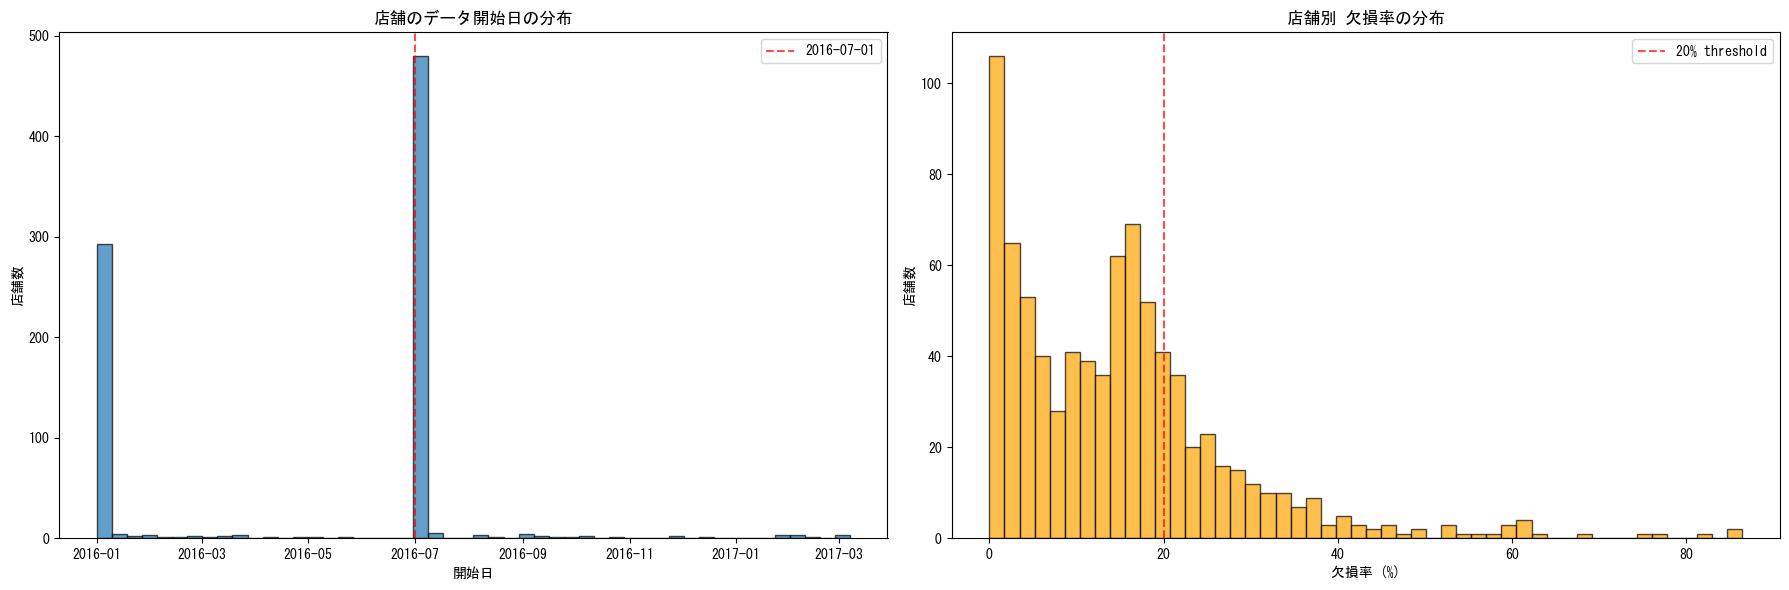

In [4]:
# 可視化 store data coverage as a heatmap (sample of stores sorted by first_date)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribution of first observation dates
axes[0].hist(store_lifecycle['first_date'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('店舗のデータ開始日の分布')
axes[0].set_xlabel('開始日')
axes[0].set_ylabel('店舗数')
axes[0].axvline(pd.Timestamp('2016-07-01'), color='red', linestyle='--', alpha=0.7, label='2016-07-01')
axes[0].legend()

# Distribution of missing rate
axes[1].hist(store_lifecycle['missing_rate'] * 100, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('店舗別 欠損率の分布')
axes[1].set_xlabel('欠損率 (%)')
axes[1].set_ylabel('店舗数')
axes[1].axvline(20, color='red', linestyle='--', alpha=0.7, label='20% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Analyze the pattern of missing days: regular weekly closure vs irregular gaps
def analyze_missing_pattern(store_id, visit_df, date_range):
    """Classify missing days for a single store."""
    store_dates = set(visit_df[visit_df['air_store_id'] == store_id]['visit_date'])
    first = min(store_dates)
    last = max(store_dates)
    active_range = pd.date_range(first, last, freq='D')
    missing = [d for d in active_range if d not in store_dates]
    if not missing:
        return pd.Series({'regular_closure_dow': -1, 'irregular_gaps': 0, 'max_consecutive_gap': 0})
    
    missing_dow = pd.Series([d.dayofweek for d in missing])
    dow_counts = missing_dow.value_counts()
    
    # If >60% of missing days fall on the same DOW, it's likely a regular closure
    total_missing = len(missing)
    most_common_dow = dow_counts.index[0]
    most_common_pct = dow_counts.iloc[0] / total_missing
    
    # Consecutive gap analysis
    missing_sorted = sorted(missing)
    consecutive = 1
    max_consecutive = 1
    for i in range(1, len(missing_sorted)):
        if (missing_sorted[i] - missing_sorted[i-1]).days == 1:
            consecutive += 1
            max_consecutive = max(max_consecutive, consecutive)
        else:
            consecutive = 1
    
    return pd.Series({
        'regular_closure_dow': most_common_dow if most_common_pct > 0.4 else -1,
        'regular_closure_pct': most_common_pct if most_common_pct > 0.4 else 0,
        'irregular_gaps': total_missing - (dow_counts.iloc[0] if most_common_pct > 0.4 else 0),
        'max_consecutive_gap': max_consecutive,
        'total_missing': total_missing
    })

# Analyze a sample of stores with missing days
stores_with_gaps = store_lifecycle[store_lifecycle['missing_days'] > 0].index
gap_analysis = pd.DataFrame({sid: analyze_missing_pattern(sid, air_visit, all_dates) 
                              for sid in stores_with_gaps}).T

dow_names = ['月', '火', '水', '木', '金', '土', '日']

print('=== Missing Day Pattern Analysis ===')
print(f'Stores with gaps: {len(gap_analysis)}')
regular = gap_analysis[gap_analysis['regular_closure_dow'] >= 0]
print(f'\nStores with regular weekly closure: {len(regular)}')
if len(regular) > 0:
    print('Regular closure day distribution:')
    for dow in range(7):
        n = (regular['regular_closure_dow'] == dow).sum()
        if n > 0:
            print(f'  {dow_names[dow]}曜日: {n} stores')

print(f'\nMax consecutive gap distribution:')
print(gap_analysis['max_consecutive_gap'].describe())
print(f'\nStores with consecutive gaps >= 7 days: {(gap_analysis["max_consecutive_gap"] >= 7).sum()}')

=== Missing Day Pattern Analysis ===
Stores with gaps: 818

Stores with regular weekly closure: 537
Regular closure day distribution:
  月曜日: 157 stores
  火曜日: 64 stores
  水曜日: 51 stores
  木曜日: 31 stores
  金曜日: 2 stores
  土曜日: 7 stores
  日曜日: 225 stores

Max consecutive gap distribution:
count    818.000000
mean       8.161369
std       18.496045
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max      256.000000
Name: max_consecutive_gap, dtype: float64

Stores with consecutive gaps >= 7 days: 217


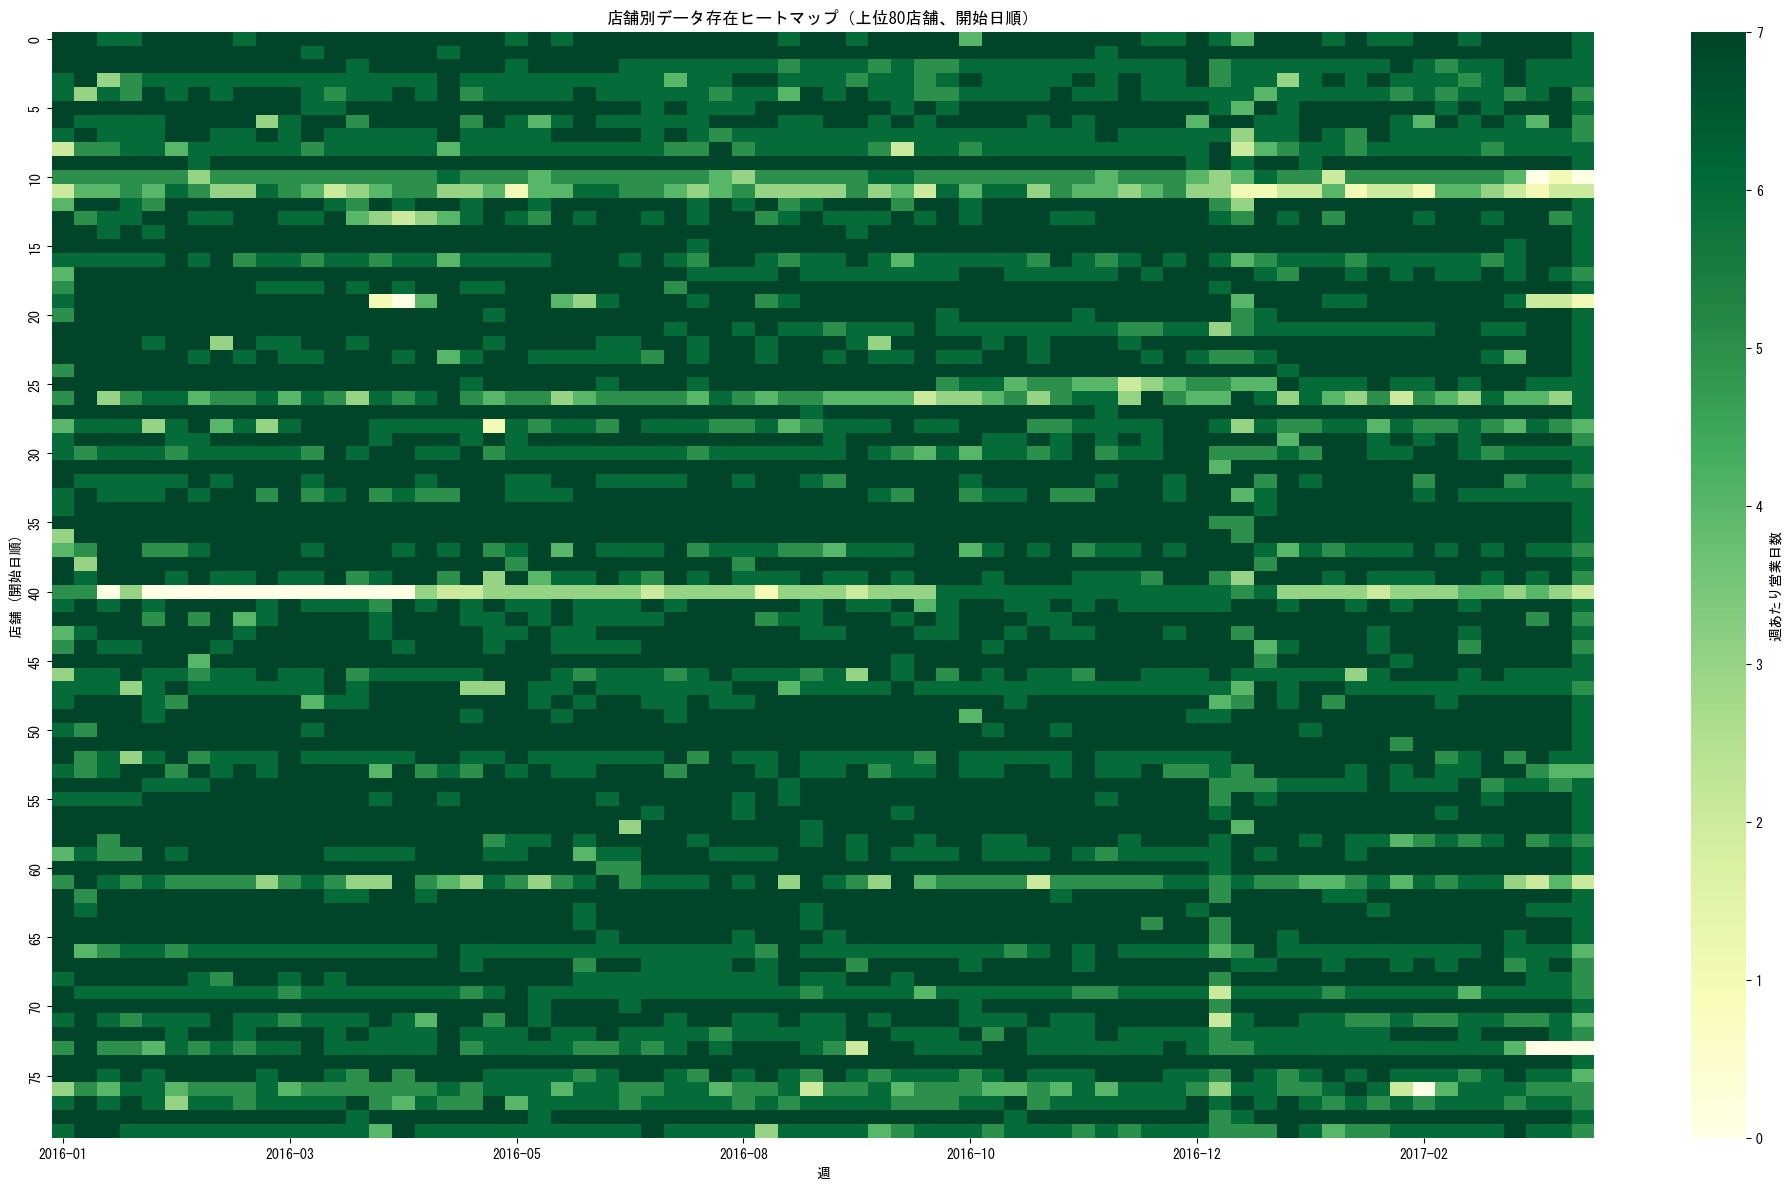

考察:
- 店舗ごとにデータ開始日が大きくばらつく
- 一部の店舗は途中でデータが途切れている（閉店 or データ欠損）
- 定休日パターン（毎週同じ曜日が欠損）を持つ店舗が多い


In [6]:
# 店舗カバレッジヒートマップ: show data presence per week for a sample of stores
# Sort stores by first_date, sample 50 for readability
sample_stores = store_lifecycle.sort_values('first_date').index[:80]
weeks = pd.date_range(all_dates.min(), all_dates.max(), freq='W-MON')

# Build presence matrix
presence = []
for sid in sample_stores:
    store_dates = set(air_visit[air_visit['air_store_id'] == sid]['visit_date'])
    row = []
    for w_start in weeks:
        w_end = w_start + pd.Timedelta(days=6)
        week_dates = pd.date_range(w_start, w_end, freq='D')
        n_present = sum(1 for d in week_dates if d in store_dates)
        row.append(n_present)
    presence.append(row)

presence_df = pd.DataFrame(presence, index=range(len(sample_stores)),
                           columns=[w.strftime('%Y-%m') for w in weeks])

fig, ax = plt.subplots(figsize=(20, 12))
sns.heatmap(presence_df, cmap='YlGn', vmin=0, vmax=7, ax=ax,
            xticklabels=10, yticklabels=5, cbar_kws={'label': '週あたり営業日数'})
ax.set_title('店舗別データ存在ヒートマップ（上位80店舗、開始日順）')
ax.set_xlabel('週')
ax.set_ylabel('店舗 (開始日順)')
plt.tight_layout()
plt.show()

print('考察:')
print('- 店舗ごとにデータ開始日が大きくばらつく')
print('- 一部の店舗は途中でデータが途切れている（閉店 or データ欠損）')
print('- 定休日パターン（毎週同じ曜日が欠損）を持つ店舗が多い')

---
## 3. データ開始日とカバレッジ分析

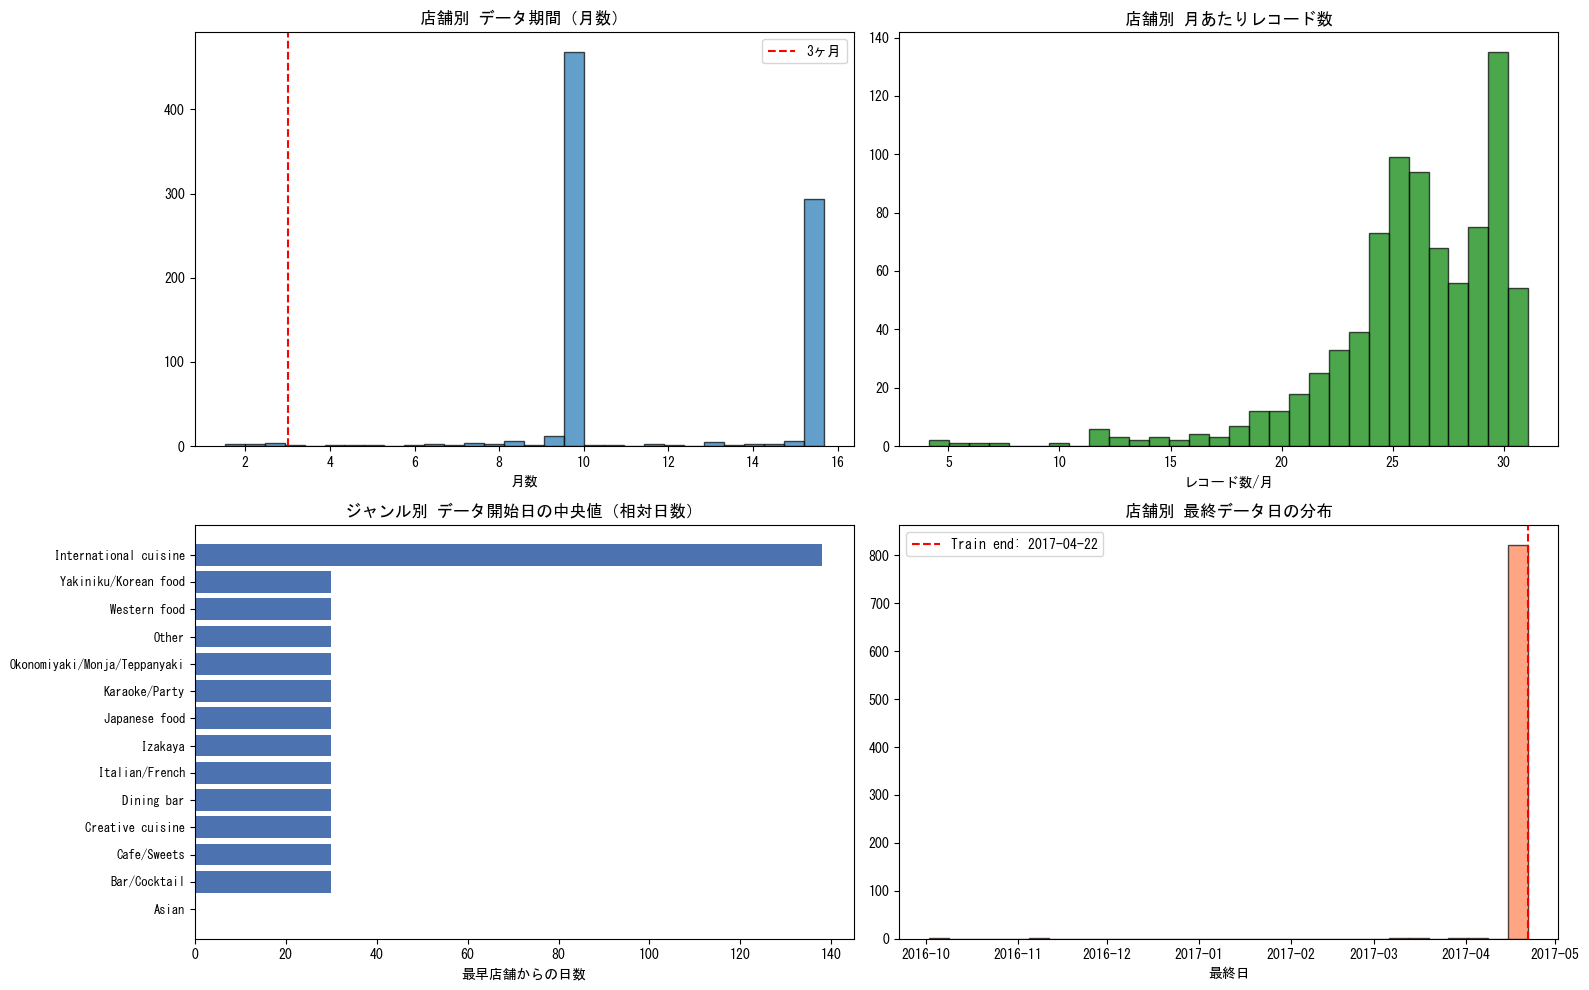

店舗が学習期間終了の30日以上前にデータ終了: 5 stores
  → これらは閉店した可能性が高い

データ期間が3ヶ月未満の店舗: 10 stores
  → 短い履歴の店舗は統計量が不安定 → 全体平均でのフォールバックが必要


In [7]:
# Data coverage by store — how many months of data does each store have?
store_lifecycle['data_months'] = (store_lifecycle['last_date'] - store_lifecycle['first_date']).dt.days / 30.44
store_lifecycle['records_per_month'] = store_lifecycle['n_records'] / store_lifecycle['data_months'].clip(lower=1)

# Merge with store info for genre analysis
store_lifecycle_info = store_lifecycle.reset_index().merge(
    air_store[['air_store_id', 'air_genre_name', 'air_area_name']], on='air_store_id'
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Data months distribution
axes[0, 0].hist(store_lifecycle['data_months'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('店舗別 データ期間（月数）')
axes[0, 0].set_xlabel('月数')
axes[0, 0].axvline(3, color='red', linestyle='--', label='3ヶ月')
axes[0, 0].legend()

# 月別レコード数
axes[0, 1].hist(store_lifecycle['records_per_month'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('店舗別 月あたりレコード数')
axes[0, 1].set_xlabel('レコード数/月')

# First date by genre
genre_first = store_lifecycle_info.groupby('air_genre_name')['first_date'].median().sort_values()
axes[1, 0].barh(range(len(genre_first)), genre_first.apply(lambda x: (x - genre_first.min()).days), color='#4C72B0')
axes[1, 0].set_yticks(range(len(genre_first)))
axes[1, 0].set_yticklabels(genre_first.index, fontsize=9)
axes[1, 0].set_title('ジャンル別 データ開始日の中央値（相対日数）')
axes[1, 0].set_xlabel('最早店舗からの日数')

# Last date distribution — check for stores that stopped reporting before end of training
axes[1, 1].hist(store_lifecycle['last_date'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_title('店舗別 最終データ日の分布')
axes[1, 1].set_xlabel('最終日')
train_end = air_visit['visit_date'].max()
axes[1, 1].axvline(train_end, color='red', linestyle='--', label=f'Train end: {train_end.date()}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Stores that stopped reporting early (potential closures)
early_stop = store_lifecycle[store_lifecycle['last_date'] < train_end - pd.Timedelta(days=30)]
print(f'店舗が学習期間終了の30日以上前にデータ終了: {len(early_stop)} stores')
print(f'  → これらは閉店した可能性が高い')
print(f'\nデータ期間が3ヶ月未満の店舗: {(store_lifecycle["data_months"] < 3).sum()} stores')
print(f'  → 短い履歴の店舗は統計量が不安定 → 全体平均でのフォールバックが必要')

---
## 4. 目的変数の分布と外れ値

=== Target Variable: visitors ===
count    252108.000000
mean         20.973761
std          16.757007
min           1.000000
25%           9.000000
50%          17.000000
75%          29.000000
max         877.000000
Name: visitors, dtype: float64

Skewness:  3.31
Kurtosis:  74.26


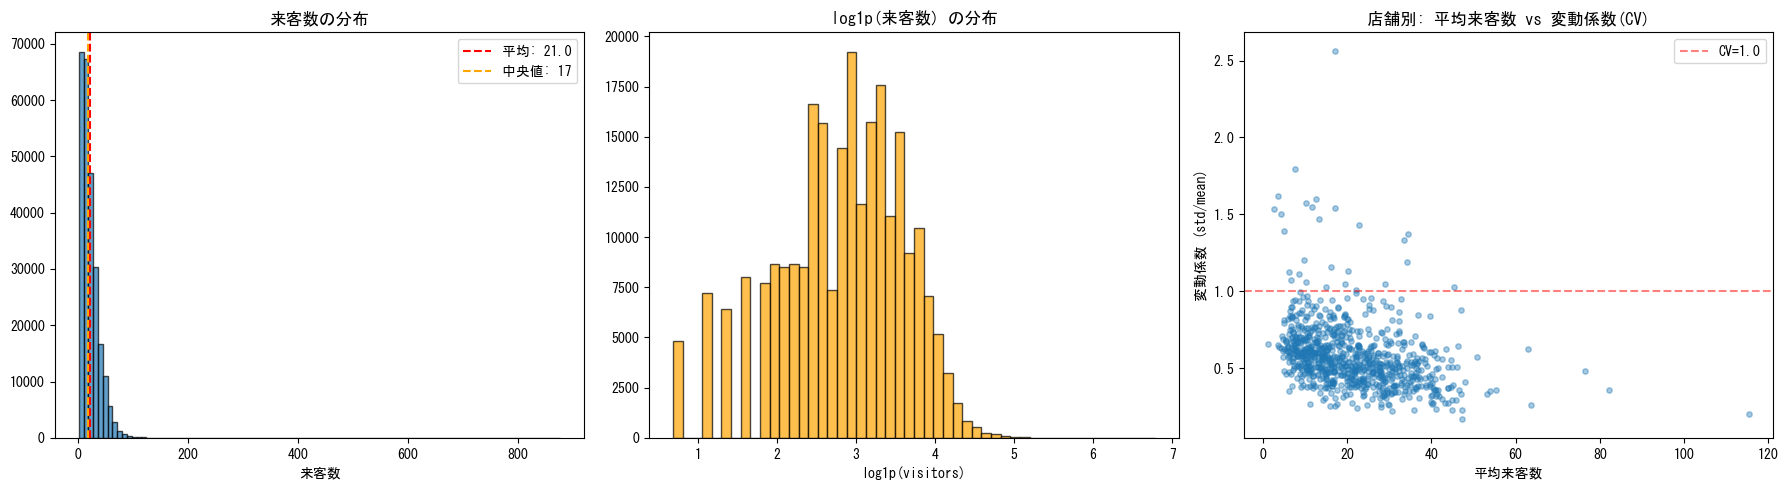


外れ値分析:
  1st percentile: 1
  99th percentile: 73
  Max: 877
  Records > 73: 2423

RMSLE評価のため log1p 変換が自然。変換後の分布は概ね正規分布に近い。


In [8]:
print('=== Target Variable: visitors ===')
print(air_visit['visitors'].describe())
print(f'\nSkewness:  {air_visit["visitors"].skew():.2f}')
print(f'Kurtosis:  {air_visit["visitors"].kurtosis():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 元の分布
axes[0].hist(air_visit['visitors'], bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(air_visit['visitors'].mean(), color='red', linestyle='--', label=f'平均: {air_visit["visitors"].mean():.1f}')
axes[0].axvline(air_visit['visitors'].median(), color='orange', linestyle='--', label=f'中央値: {air_visit["visitors"].median():.0f}')
axes[0].set_title('来客数の分布')
axes[0].set_xlabel('来客数')
axes[0].legend()

# Log-transformed
log_visitors = np.log1p(air_visit['visitors'])
axes[1].hist(log_visitors, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('log1p(来客数) の分布')
axes[1].set_xlabel('log1p(visitors)')

# 店舗別変動係数 (coefficient of variation)
store_cv = air_visit.groupby('air_store_id')['visitors'].agg(['mean', 'std'])
store_cv['cv'] = store_cv['std'] / store_cv['mean']
axes[2].scatter(store_cv['mean'], store_cv['cv'], alpha=0.4, s=15)
axes[2].set_title('店舗別: 平均来客数 vs 変動係数(CV)')
axes[2].set_xlabel('平均来客数')
axes[2].set_ylabel('変動係数 (std/mean)')
axes[2].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='CV=1.0')
axes[2].legend()

plt.tight_layout()
plt.show()

# Outlier analysis
q99 = air_visit['visitors'].quantile(0.99)
q01 = air_visit['visitors'].quantile(0.01)
print(f'\n外れ値分析:')
print(f'  1st percentile: {q01:.0f}')
print(f'  99th percentile: {q99:.0f}')
print(f'  Max: {air_visit["visitors"].max()}')
print(f'  Records > {q99:.0f}: {(air_visit["visitors"] > q99).sum()}')
print(f'\nRMSLE評価のため log1p 変換が自然。変換後の分布は概ね正規分布に近い。')

---
## 5. 時系列パターン（曜日・月・年）

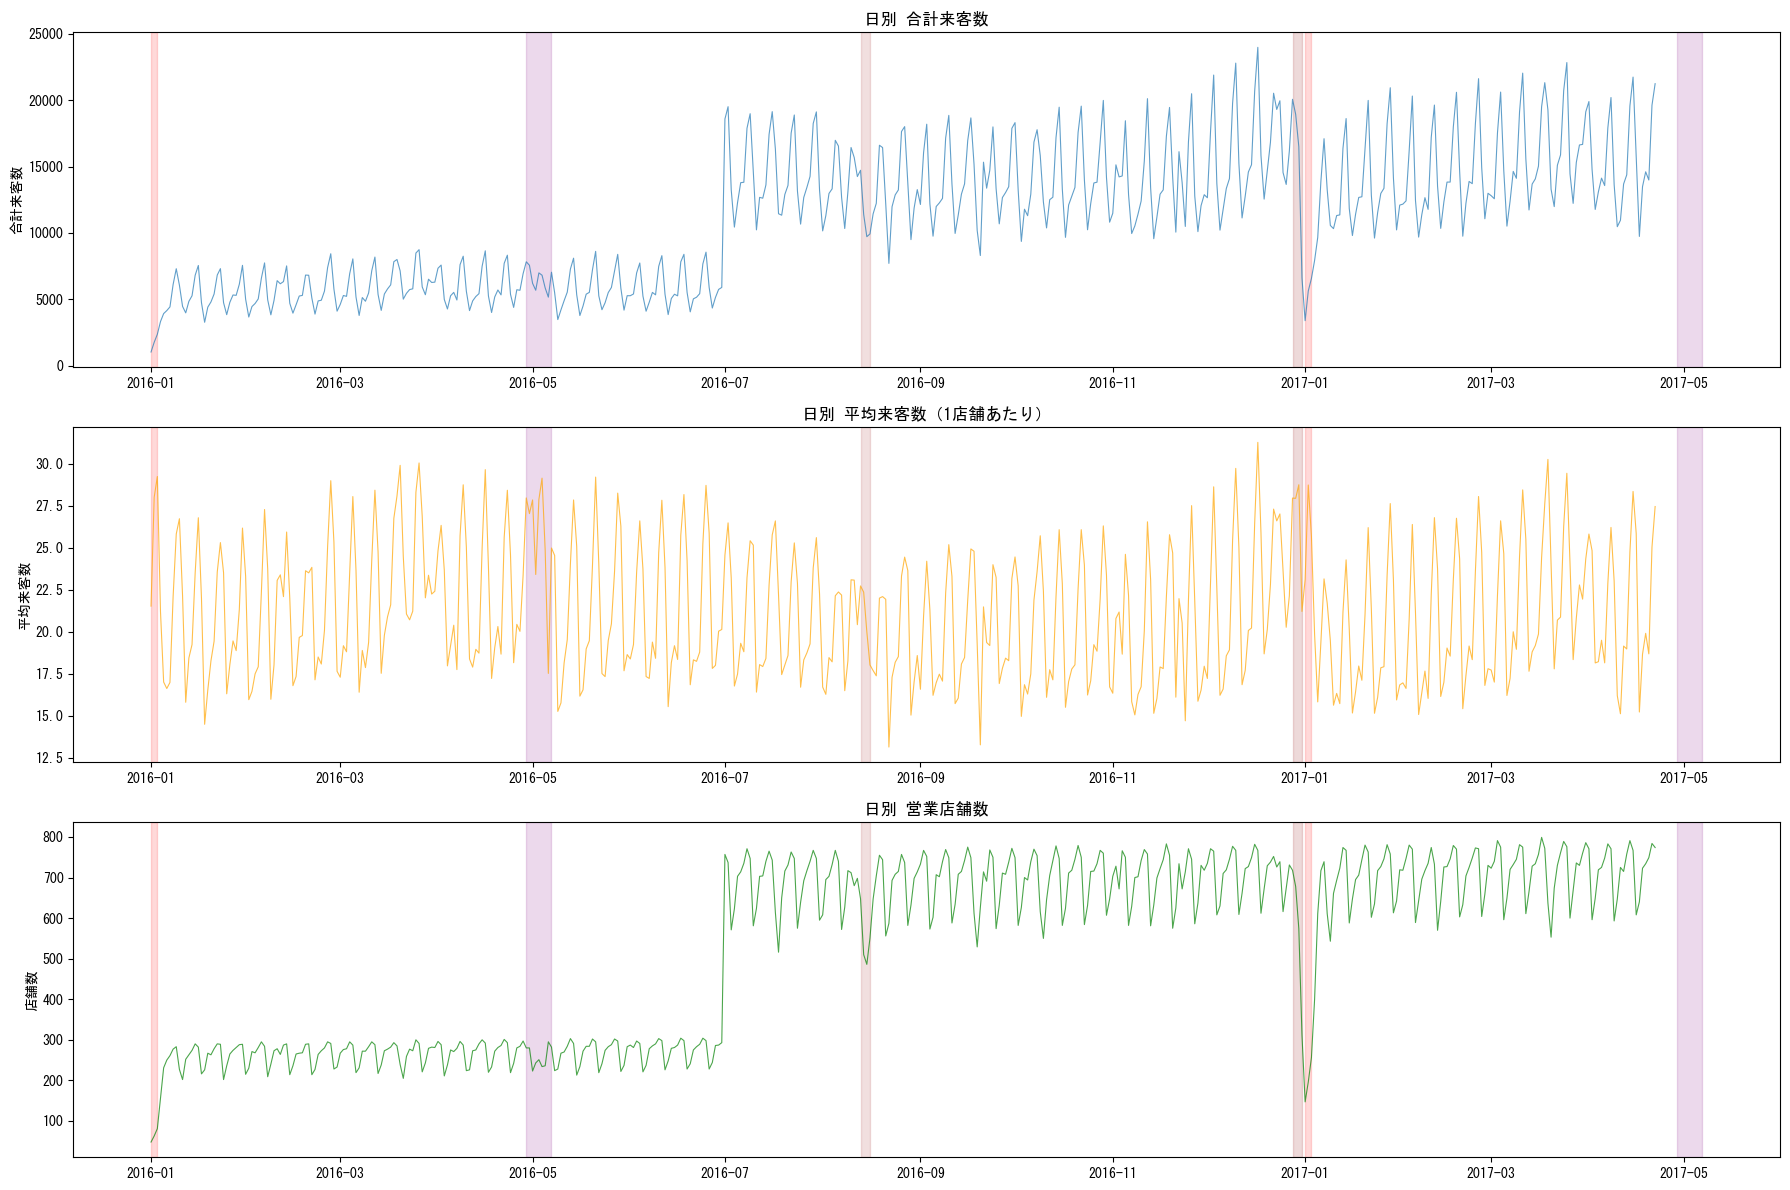

考察:
- 明確な週次パターン（金土にピーク）
- 12月に大きなピーク（忘年会シーズン）
- 正月・GW・お盆で営業店舗数が大幅に減少
- テスト期間(4/23-5/31)にGWが含まれる → 重要なリスク要因


In [9]:
# 日次集計時系列
daily = air_visit.groupby('visit_date')['visitors'].agg(['sum', 'mean', 'count']).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(18, 12))

axes[0].plot(daily['visit_date'], daily['sum'], alpha=0.7, linewidth=0.8)
axes[0].set_title('日別 合計来客数')
axes[0].set_ylabel('合計来客数')

axes[1].plot(daily['visit_date'], daily['mean'], alpha=0.7, color='orange', linewidth=0.8)
axes[1].set_title('日別 平均来客数（1店舗あたり）')
axes[1].set_ylabel('平均来客数')

axes[2].plot(daily['visit_date'], daily['count'], alpha=0.7, color='green', linewidth=0.8)
axes[2].set_title('日別 営業店舗数')
axes[2].set_ylabel('店舗数')

# Mark special periods
for ax in axes:
    for label, start, end, color in [
        ('正月2016', '2016-01-01', '2016-01-03', 'red'),
        ('GW2016', '2016-04-29', '2016-05-07', 'purple'),
        ('お盆2016', '2016-08-13', '2016-08-16', 'brown'),
        ('年末2016', '2016-12-28', '2016-12-31', 'darkred'),
        ('正月2017', '2017-01-01', '2017-01-03', 'red'),
        ('GW2017(テスト期間)', '2017-04-29', '2017-05-07', 'purple'),
    ]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=color)

plt.tight_layout()
plt.show()

print('考察:')
print('- 明確な週次パターン（金土にピーク）')
print('- 12月に大きなピーク（忘年会シーズン）')
print('- 正月・GW・お盆で営業店舗数が大幅に減少')
print('- テスト期間(4/23-5/31)にGWが含まれる → 重要なリスク要因')

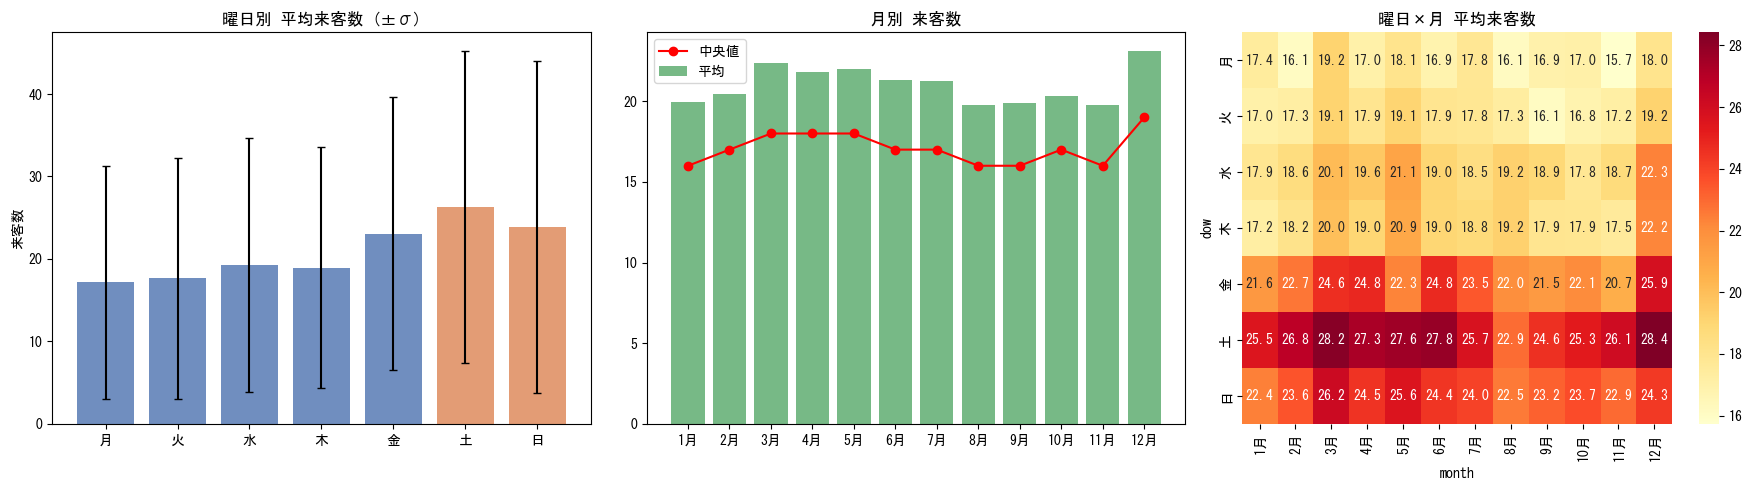

=== 前年同月比 (平均来客数) ===
  1月: 2016=20.9 → 2017=19.6 (-6.0%)
  2月: 2016=21.0 → 2017=20.3 (-3.7%)
  3月: 2016=22.9 → 2017=22.2 (-2.8%)
  4月: 2016=22.5 → 2017=21.4 (-4.8%)


In [10]:
# DOW, Month, DOW×Month patterns
air_visit['dow'] = air_visit['visit_date'].dt.dayofweek
air_visit['month'] = air_visit['visit_date'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DOW effect
dow_stats = air_visit.groupby('dow')['visitors'].agg(['mean', 'median', 'std'])
colors = ['#4C72B0'] * 5 + ['#DD8452'] * 2
axes[0].bar(range(7), dow_stats['mean'], yerr=dow_stats['std'], color=colors, capsize=3, alpha=0.8)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_names)
axes[0].set_title('曜日別 平均来客数 (±σ)')
axes[0].set_ylabel('来客数')

# Month effect
month_stats = air_visit.groupby('month')['visitors'].agg(['mean', 'median'])
axes[1].bar(range(1, 13), month_stats['mean'], color='#55A868', alpha=0.8, label='平均')
axes[1].plot(range(1, 13), month_stats['median'], 'o-', color='red', label='中央値')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([f'{m}月' for m in range(1, 13)])
axes[1].set_title('月別 来客数')
axes[1].legend()

# DOW × Month heatmap
dow_month = air_visit.groupby(['dow', 'month'])['visitors'].mean().unstack()
sns.heatmap(dow_month, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=[f'{m}月' for m in range(1, 13)],
            yticklabels=dow_names, ax=axes[2])
axes[2].set_title('曜日×月 平均来客数')

plt.tight_layout()
plt.show()

# 年度別比較 (months that exist in both years)
air_visit['year'] = air_visit['visit_date'].dt.year
yoy = air_visit.groupby(['year', 'month'])['visitors'].mean().unstack(level=0)
if 2016 in yoy.columns and 2017 in yoy.columns:
    common_months = yoy.dropna().index
    print('=== 前年同月比 (平均来客数) ===')
    for m in common_months:
        change = (yoy.loc[m, 2017] / yoy.loc[m, 2016] - 1) * 100
        print(f'  {m}月: 2016={yoy.loc[m, 2016]:.1f} → 2017={yoy.loc[m, 2017]:.1f} ({change:+.1f}%)')

---
## 6. 自己相関とSTL分解

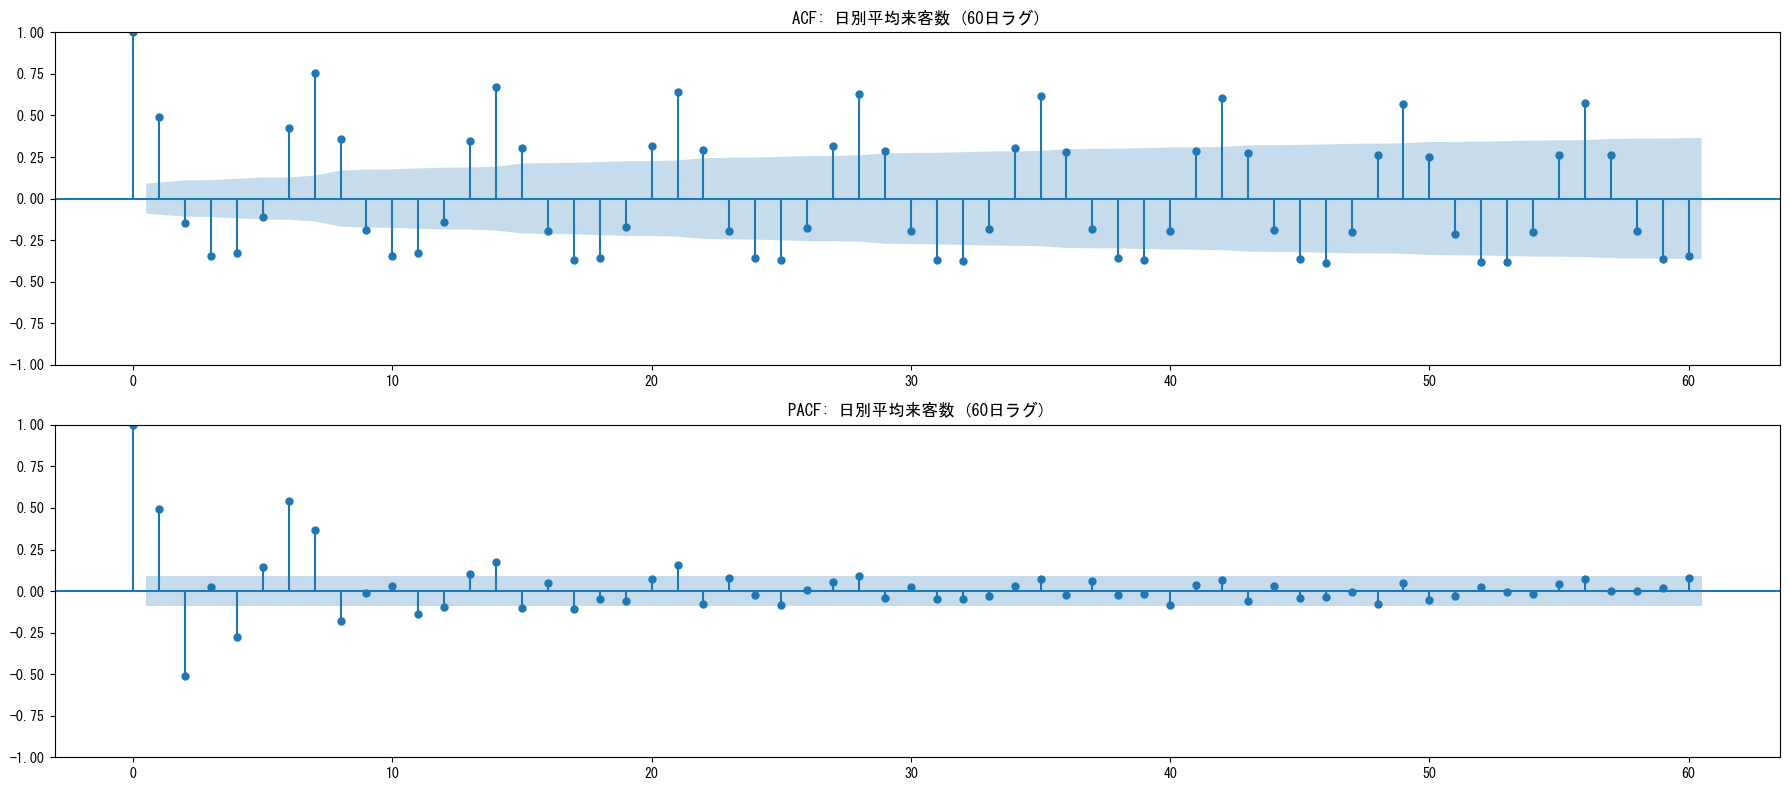

考察:
- ACF: lag=7で強い自己相関 → 週次周期が最も支配的
- lag=14, 21, 28... でも周期的なスパイク
- PACF: lag=1とlag=7が有意 → AR(1)+季節AR(7)の構造
→ 特徴量として lag_1, lag_7, lag_14, lag_21, lag_28 が有力候補


In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

# ACF / PACF on aggregated daily mean visitors
daily_mean = daily.set_index('visit_date')['mean'].asfreq('D').interpolate()

fig, axes = plt.subplots(2, 1, figsize=(18, 8))
plot_acf(daily_mean, lags=60, ax=axes[0], title='ACF: 日別平均来客数 (60日ラグ)')
plot_pacf(daily_mean, lags=60, ax=axes[1], title='PACF: 日別平均来客数 (60日ラグ)')
plt.tight_layout()
plt.show()

print('考察:')
print('- ACF: lag=7で強い自己相関 → 週次周期が最も支配的')
print('- lag=14, 21, 28... でも周期的なスパイク')
print('- PACF: lag=1とlag=7が有意 → AR(1)+季節AR(7)の構造')
print('→ 特徴量として lag_1, lag_7, lag_14, lag_21, lag_28 が有力候補')

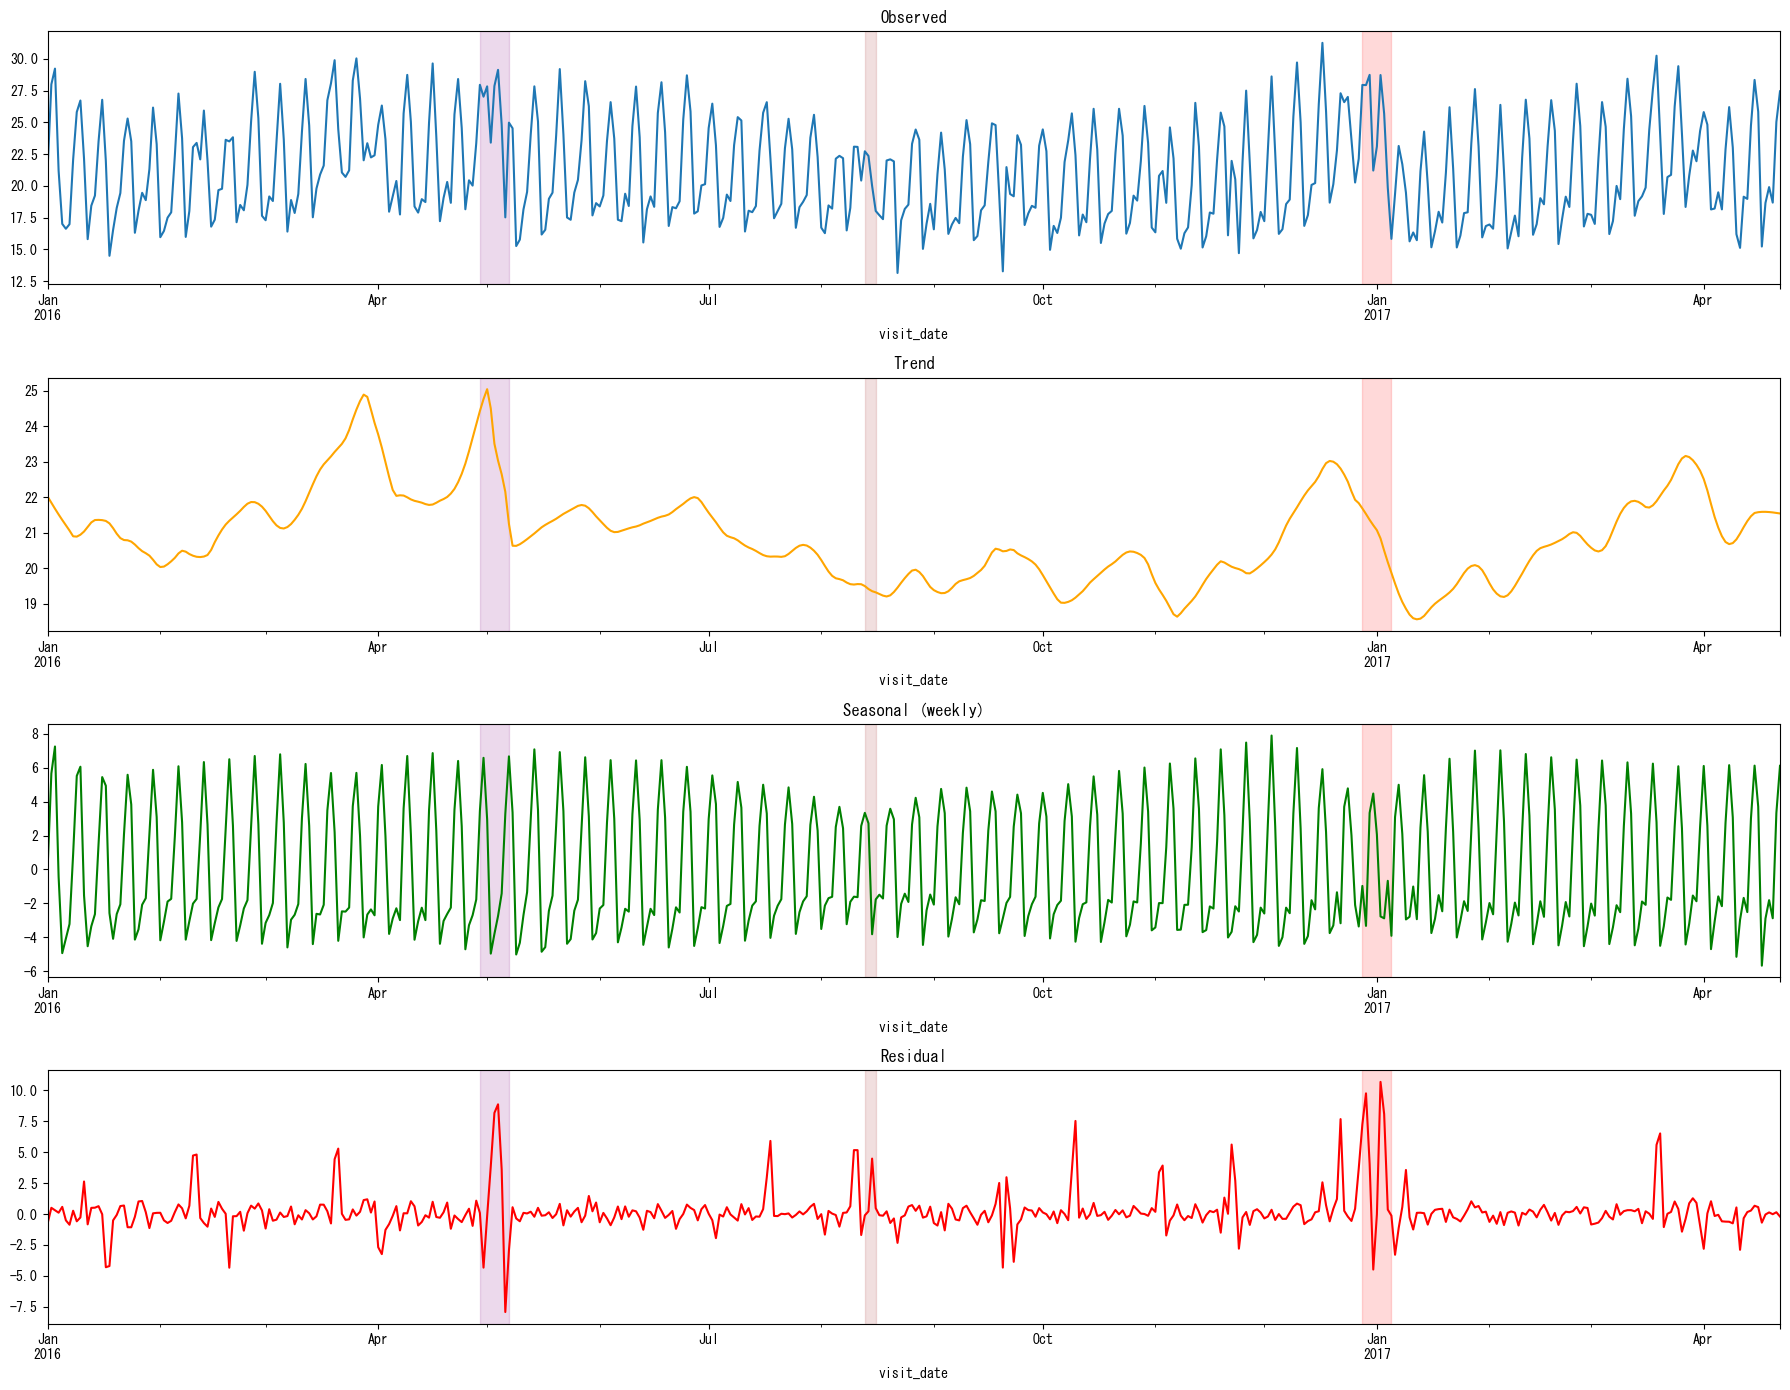

=== Residual (STL) の大きい日付 ===
  2017-01-02 (月): residual = +10.7 ↑
  2016-12-29 (木): residual = +9.7 ↑
  2016-05-04 (水): residual = +8.9 ↑
  2016-05-03 (火): residual = +8.2 ↑
  2017-01-03 (火): residual = +8.1 ↑
  2016-05-06 (金): residual = -7.9 ↓
  2016-12-22 (木): residual = +7.7 ↑
  2016-10-10 (月): residual = +7.5 ↑
  2016-12-28 (水): residual = +7.2 ↑
  2017-03-20 (月): residual = +6.5 ↑
  2016-07-18 (月): residual = +5.9 ↑
  2016-11-22 (火): residual = +5.6 ↑
  2017-03-19 (日): residual = +5.6 ↑
  2016-03-21 (月): residual = +5.3 ↑
  2016-08-10 (水): residual = +5.2 ↑

考察:
- トレンド成分: 緩やかな上昇傾向（店舗数増加の影響も含む）
- 季節成分: 金土が高く月火が低い、安定した週次パターン
- 残差が大きい日: 祝日・特殊イベントに対応 → 特殊期間フラグが必要


In [12]:
# STL分解 (period=7 for weekly seasonality)
stl = STL(daily_mean, period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(18, 14))
result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1], title='Trend', color='orange')
result.seasonal.plot(ax=axes[2], title='Seasonal (weekly)', color='green')
result.resid.plot(ax=axes[3], title='Residual', color='red')

for ax in axes:
    for label, start, end, color in [
        ('NY', '2016-12-28', '2017-01-05', 'red'),
        ('GW', '2016-04-29', '2016-05-07', 'purple'),
        ('Obon', '2016-08-13', '2016-08-16', 'brown'),
    ]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=color)

plt.tight_layout()
plt.show()

# Residual statistics — large residuals indicate anomalous periods
resid = result.resid.dropna()
print('=== Residual (STL) の大きい日付 ===')
large_resid = resid.abs().nlargest(15)
for date, val in large_resid.items():
    direction = '↑' if resid[date] > 0 else '↓'
    print(f'  {date.date()} ({dow_names[date.dayofweek]}): residual = {resid[date]:+.1f} {direction}')

print('\n考察:')
print('- トレンド成分: 緩やかな上昇傾向（店舗数増加の影響も含む）')
print('- 季節成分: 金土が高く月火が低い、安定した週次パターン')
print('- 残差が大きい日: 祝日・特殊イベントに対応 → 特殊期間フラグが必要')

---
## 7. 祝日・特別期間分析

| 期間 | 日付範囲 | 特徴 |
|------|----------|------|
| 正月 | 12/31〜1/3 | 多くの店舗が休業、来客数が大幅減少 |
| ゴールデンウィーク (GW) | 4/29〜5/5 | 連休、外食需要増加 |
| お盆 | 8/13〜8/16 | 帰省シーズン、地域差あり |
| シルバーウィーク | 9/19〜9/22 (2016) | 連休 |
| 年末 | 12/25〜12/30 | 忘年会シーズン、来客数増加 |
| クリスマス | 12/23〜12/25 | 外食需要増加 |
| バレンタイン | 2/14 | 軽微な影響 |

In [13]:
# 7a. Define special periods and analyze raw visitor behavior
special_periods = {
    'New Year 2016':     ('2016-01-01', '2016-01-03'),
    'New Year 2017':     ('2017-01-01', '2017-01-03'),
    'GW 2016':           ('2016-04-29', '2016-05-05'),
    'Obon 2016':         ('2016-08-13', '2016-08-16'),
    'Silver Week 2016':  ('2016-09-17', '2016-09-19'),
    'Christmas 2016':    ('2016-12-23', '2016-12-25'),
    'Year-end 2016':     ('2016-12-28', '2016-12-31'),
}

# Merge visit data with date_info
visit_full = air_visit.merge(
    date_info.rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)

# For each special period: how many stores operated, and how did visitors compare to normal?
print('=== Special Period Analysis (Raw Data) ===')
print(f'{"Period":<22s} {"Dates":<28s} {"Stores":>7s} {"Avg Visitors":>13s} {"vs Normal":>10s} {"Store Drop":>11s}')
print('-' * 95)

# Normal baseline per store (excluding all special periods)
all_special_dates = set()
for start, end in special_periods.values():
    all_special_dates.update(pd.date_range(start, end))

normal_mask = ~air_visit['visit_date'].isin(all_special_dates)
normal_store_mean = air_visit[normal_mask].groupby('air_store_id')['visitors'].mean()
normal_daily_stores = air_visit[normal_mask].groupby('visit_date')['air_store_id'].nunique().mean()

for period_name, (start, end) in special_periods.items():
    mask = (air_visit['visit_date'] >= start) & (air_visit['visit_date'] <= end)
    period_data = air_visit[mask]
    if len(period_data) == 0:
        continue
    
    n_stores = period_data['air_store_id'].nunique()
    avg_daily_stores = period_data.groupby('visit_date')['air_store_id'].nunique().mean()
    avg_visitors = period_data['visitors'].mean()
    
    # Compare to normal for stores that operated during this period
    operating_stores = period_data['air_store_id'].unique()
    normal_avg = normal_store_mean.loc[normal_store_mean.index.isin(operating_stores)].mean()
    vs_normal = (avg_visitors / normal_avg - 1) * 100 if normal_avg > 0 else 0
    store_drop = (1 - avg_daily_stores / normal_daily_stores) * 100
    
    print(f'{period_name:<22s} {start} ~ {end}  {avg_daily_stores:>6.0f}  {avg_visitors:>12.1f}  {vs_normal:>+9.1f}%  {store_drop:>+10.1f}%')

=== Special Period Analysis (Raw Data) ===
Period                 Dates                         Stores  Avg Visitors  vs Normal  Store Drop
-----------------------------------------------------------------------------------------------
New Year 2016          2016-01-01 ~ 2016-01-03      64          26.9      +30.6%       +88.0%
New Year 2017          2017-01-01 ~ 2017-01-03     200          26.0      +27.8%       +62.7%
GW 2016                2016-04-29 ~ 2016-05-05     250          26.9      +30.6%       +53.3%
Obon 2016              2016-08-13 ~ 2016-08-16     549          20.9       +1.3%        -2.6%
Silver Week 2016       2016-09-17 ~ 2016-09-19     630          23.3      +13.8%       -17.8%
Christmas 2016         2016-12-23 ~ 2016-12-25     694          25.9      +25.7%       -29.7%
Year-end 2016          2016-12-28 ~ 2016-12-31     570          27.2      +33.5%        -6.7%


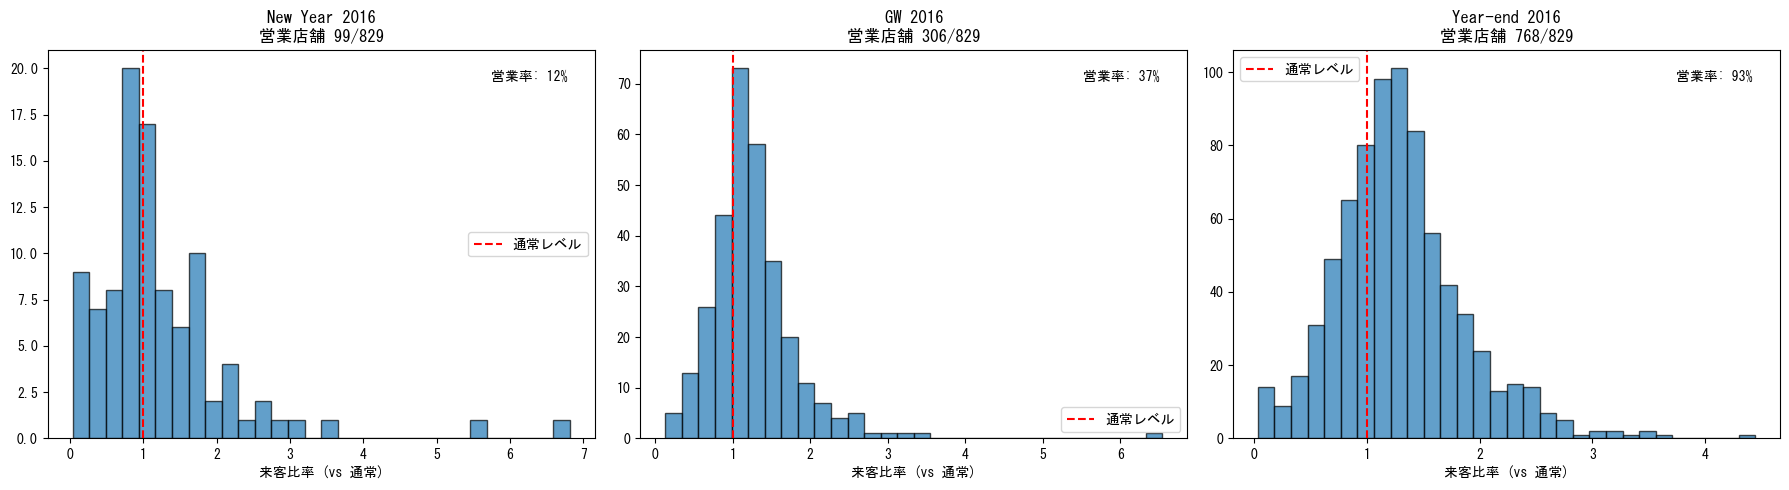

=== 年末期間 ジャンル別来客比率 ===
  Yakiniku/Korean food               : 1.60x (n=22)
  Izakaya                            : 1.48x (n=190)
  Dining bar                         : 1.39x (n=107)
  Bar/Cocktail                       : 1.33x (n=76)
  Japanese food                      : 1.27x (n=62)
  Okonomiyaki/Monja/Teppanyaki       : 1.21x (n=12)
  Italian/French                     : 1.19x (n=90)
  Other                              : 1.15x (n=26)
  Western food                       : 1.14x (n=12)
  Creative cuisine                   : 1.13x (n=12)
  Cafe/Sweets                        : 1.04x (n=155)


In [14]:
# 7b. Per-store holiday behavior patterns
# For each store: did it operate during each special period, and if so, what was the visitor ratio?

def store_period_ratio(store_id, period_start, period_end, visit_df, normal_means):
    """Compute visitor ratio for a store during a specific period vs its normal."""
    mask = (visit_df['air_store_id'] == store_id) & \
           (visit_df['visit_date'] >= period_start) & \
           (visit_df['visit_date'] <= period_end)
    period_data = visit_df[mask]
    
    if len(period_data) == 0:
        return np.nan  # Store did not operate
    
    normal = normal_means.get(store_id, np.nan)
    if pd.isna(normal) or normal == 0:
        return np.nan
    
    return period_data['visitors'].mean() / normal

# Compute for key periods
key_periods = {
    'New Year 2016': ('2016-01-01', '2016-01-03'),
    'GW 2016': ('2016-04-29', '2016-05-05'),
    'Year-end 2016': ('2016-12-28', '2016-12-31'),
}

normal_means_dict = normal_store_mean.to_dict()
store_ids = air_visit['air_store_id'].unique()

ratios = {}
for period_name, (start, end) in key_periods.items():
    ratios[period_name] = {
        sid: store_period_ratio(sid, start, end, air_visit, normal_means_dict)
        for sid in store_ids
    }

ratio_df = pd.DataFrame(ratios)
# Merge with genre for analysis
ratio_with_genre = ratio_df.join(
    air_store.set_index('air_store_id')['air_genre_name']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, period_name in enumerate(key_periods.keys()):
    data = ratio_df[period_name].dropna()
    axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7)
    axes[i].axvline(1.0, color='red', linestyle='--', label='通常レベル')
    axes[i].set_title(f'{period_name}\n営業店舗 {data.notna().sum()}/{len(store_ids)}')
    axes[i].set_xlabel('来客比率 (vs 通常)')
    operated_pct = len(data) / len(store_ids) * 100
    axes[i].annotate(f'営業率: {operated_pct:.0f}%', xy=(0.95, 0.95),
                     xycoords='axes fraction', ha='right', va='top', fontsize=10)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Genre breakdown for year-end
print('=== 年末期間 ジャンル別来客比率 ===')
genre_year_end = ratio_with_genre.groupby('air_genre_name')['Year-end 2016'].agg(['mean', 'count'])
genre_year_end = genre_year_end[genre_year_end['count'] >= 5].sort_values('mean', ascending=False)
for genre, row in genre_year_end.iterrows():
    print(f'  {genre:<35s}: {row["mean"]:.2f}x (n={row["count"]:.0f})')

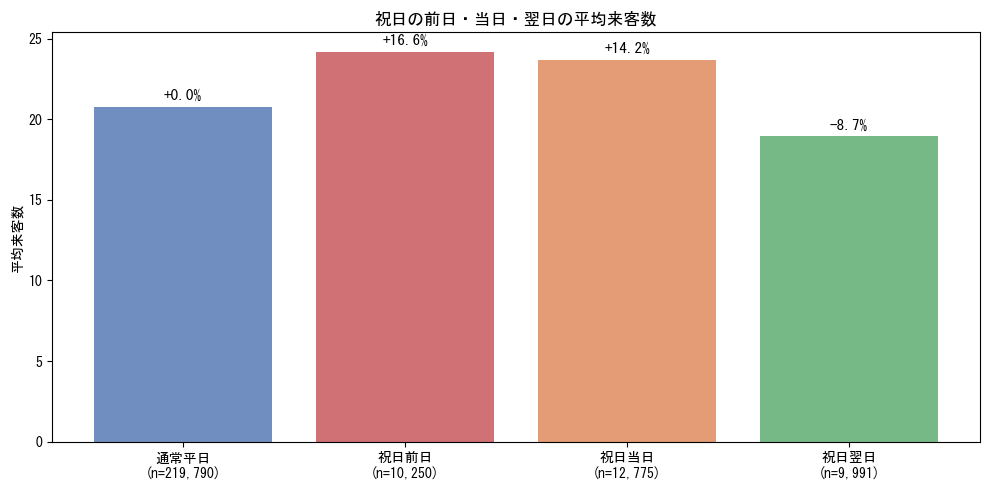

考察:
- 祝日前日は通常平日より来客が増加（飲み会前日効果）
- 祝日翌日は反動減の可能性
→ is_before_holiday, is_after_holiday を特徴量に追加すべき


In [15]:
# 7c. Adjacent-day effects: day before and after holidays
# Create holiday flags for before/after
date_info_ext = date_info.copy()
date_info_ext = date_info_ext.sort_values('calendar_date').reset_index(drop=True)
date_info_ext['holiday_tomorrow'] = date_info_ext['holiday_flg'].shift(-1).fillna(0).astype(int)
date_info_ext['holiday_yesterday'] = date_info_ext['holiday_flg'].shift(1).fillna(0).astype(int)
date_info_ext['is_before_holiday'] = ((date_info_ext['holiday_flg'] == 0) & (date_info_ext['holiday_tomorrow'] == 1)).astype(int)
date_info_ext['is_after_holiday'] = ((date_info_ext['holiday_flg'] == 0) & (date_info_ext['holiday_yesterday'] == 1)).astype(int)

visit_ext = air_visit.merge(
    date_info_ext.rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)

# Compare: normal weekday / before holiday / holiday / after holiday
categories = {
    '通常平日': (visit_ext['holiday_flg'] == 0) & (visit_ext['is_before_holiday'] == 0) & (visit_ext['is_after_holiday'] == 0),
    '祝日前日': visit_ext['is_before_holiday'] == 1,
    '祝日当日': visit_ext['holiday_flg'] == 1,
    '祝日翌日': visit_ext['is_after_holiday'] == 1,
}

fig, ax = plt.subplots(figsize=(10, 5))
means = []
labels = []
for label, mask in categories.items():
    data = visit_ext[mask]['visitors']
    means.append(data.mean())
    labels.append(f'{label}\n(n={len(data):,})')

colors = ['#4C72B0', '#C44E52', '#DD8452', '#55A868']
bars = ax.bar(labels, means, color=colors, alpha=0.8)
ax.set_title('祝日の前日・当日・翌日の平均来客数')
ax.set_ylabel('平均来客数')

# Add percentage labels
baseline = means[0]
for bar, mean in zip(bars, means):
    pct = (mean / baseline - 1) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:+.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print('考察:')
print('- 祝日前日は通常平日より来客が増加（飲み会前日効果）')
print('- 祝日翌日は反動減の可能性')
print('→ is_before_holiday, is_after_holiday を特徴量に追加すべき')

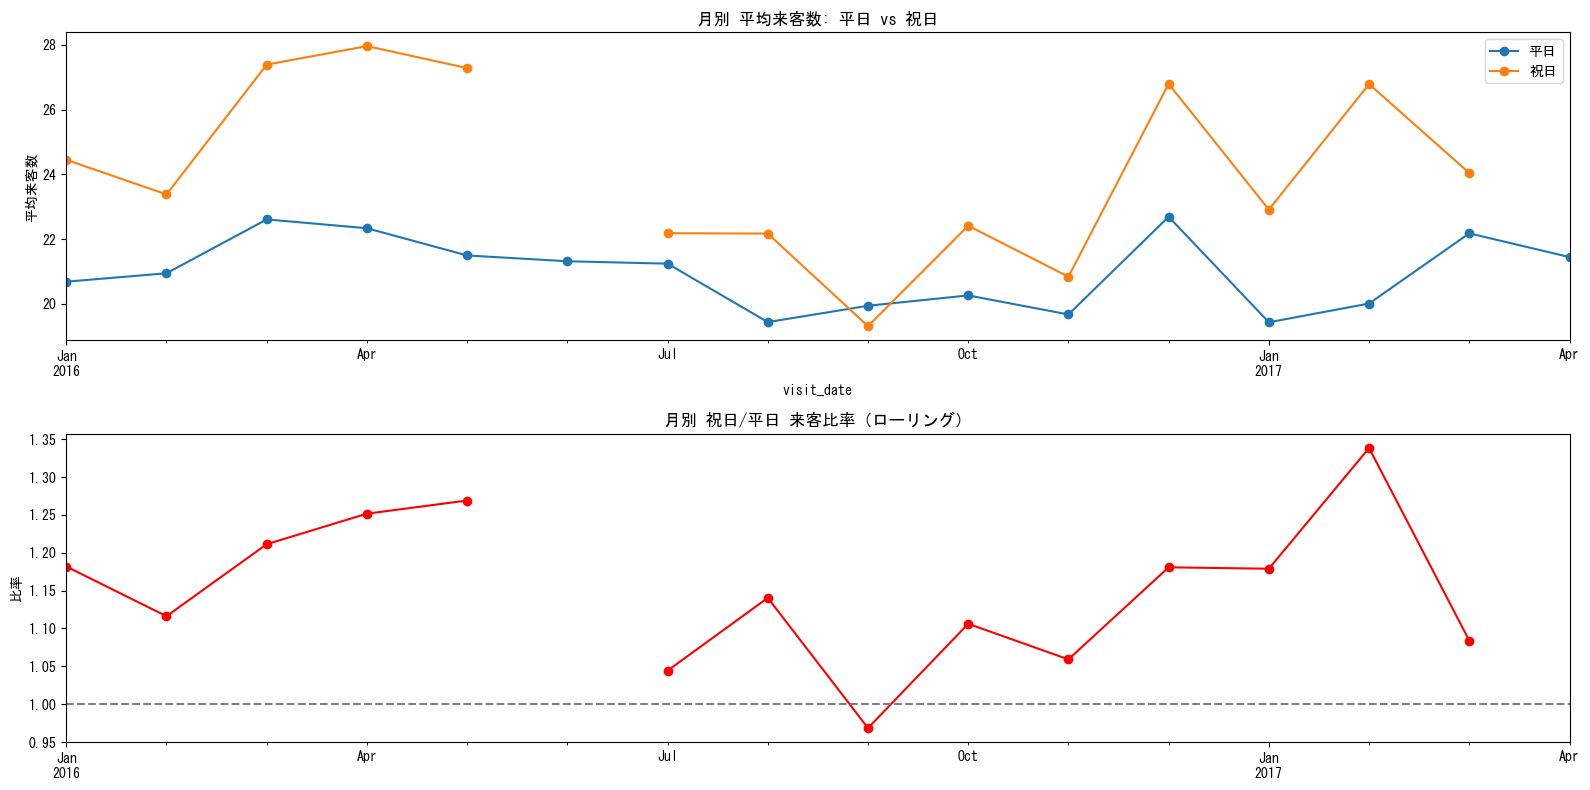

考察:
- 祝日効果は月によって大きく異なる
- 12月の祝日（天皇誕生日等）は忘年会効果と重なり特に大きい
- 一律の祝日フラグではなく、月×祝日の交互作用が必要


In [16]:
# 7d. Rolling holiday effect — is the holiday impact stable over time?
# Compute rolling 4-week window: average visitors on holidays vs non-holidays
visit_ext['is_weekend'] = visit_ext['dow'].isin([5, 6]).astype(int)

# Monthly rolling: holiday effect ratio
monthly_effect = visit_ext.groupby([visit_ext['visit_date'].dt.to_period('M'), 'holiday_flg'])['visitors'].mean().unstack()
if 0 in monthly_effect.columns and 1 in monthly_effect.columns:
    monthly_effect['ratio'] = monthly_effect[1] / monthly_effect[0]
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    
    monthly_effect[[0, 1]].plot(ax=axes[0], marker='o')
    axes[0].set_title('月別 平均来客数: 平日 vs 祝日')
    axes[0].set_ylabel('平均来客数')
    axes[0].legend(['平日', '祝日'])
    
    monthly_effect['ratio'].plot(ax=axes[1], marker='o', color='red')
    axes[1].axhline(1.0, color='gray', linestyle='--')
    axes[1].set_title('月別 祝日/平日 来客比率（ローリング）')
    axes[1].set_ylabel('比率')
    axes[1].set_xlabel('')
    
    plt.tight_layout()
    plt.show()
    
    print('考察:')
    print('- 祝日効果は月によって大きく異なる')
    print('- 12月の祝日（天皇誕生日等）は忘年会効果と重なり特に大きい')
    print('- 一律の祝日フラグではなく、月×祝日の交互作用が必要')
else:
    print('Note: Not enough holiday data for monthly breakdown')

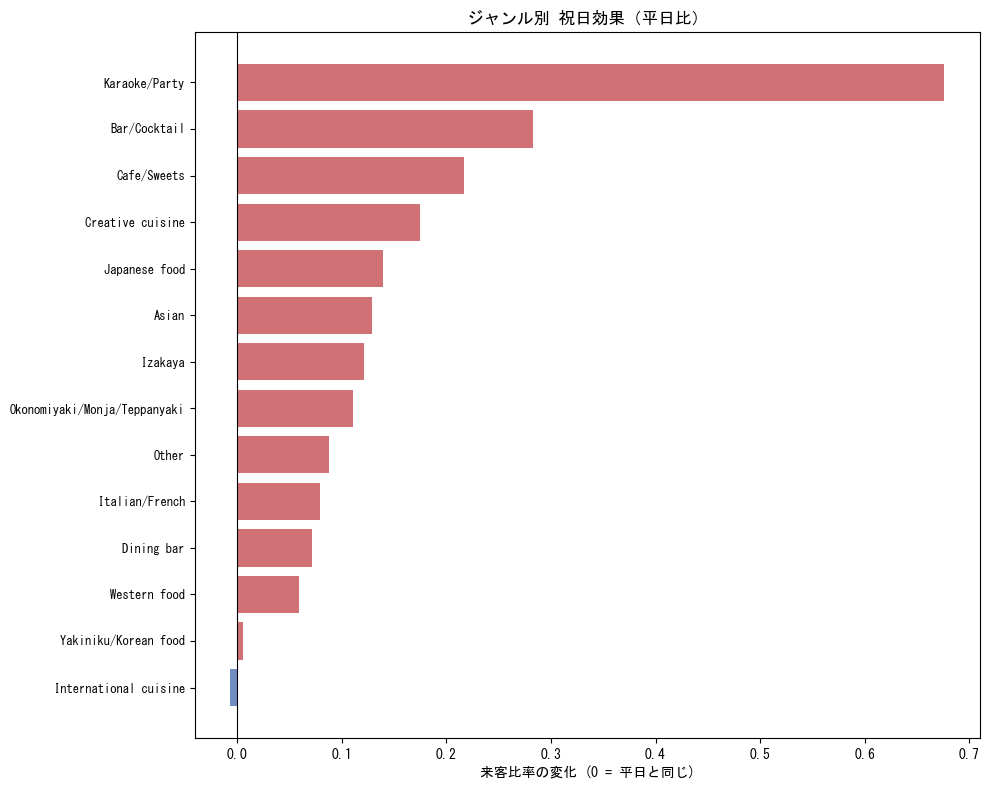

考察:
- ジャンルにより祝日の影響が正反対
- → ジャンル×祝日の交互作用特徴量が有効


In [17]:
# 7e. Genre-specific holiday response
# Which genres surge vs decline during holidays?
visit_genre = visit_ext.merge(air_store[['air_store_id', 'air_genre_name']], on='air_store_id')

genre_holiday = visit_genre.groupby(['air_genre_name', 'holiday_flg'])['visitors'].mean().unstack()
if 0 in genre_holiday.columns and 1 in genre_holiday.columns:
    genre_holiday['ratio'] = genre_holiday[1] / genre_holiday[0]
    genre_holiday = genre_holiday.sort_values('ratio', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#C44E52' if r > 1 else '#4C72B0' for r in genre_holiday['ratio']]
    ax.barh(range(len(genre_holiday)), genre_holiday['ratio'] - 1, color=colors, alpha=0.8)
    ax.set_yticks(range(len(genre_holiday)))
    ax.set_yticklabels(genre_holiday.index, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('ジャンル別 祝日効果（平日比）')
    ax.set_xlabel('来客比率の変化 (0 = 平日と同じ)')
    
    plt.tight_layout()
    plt.show()
    
    print('考察:')
    print('- ジャンルにより祝日の影響が正反対')
    print('- → ジャンル×祝日の交互作用特徴量が有効')

---
## 8. 店舗・ジャンル・地域分析

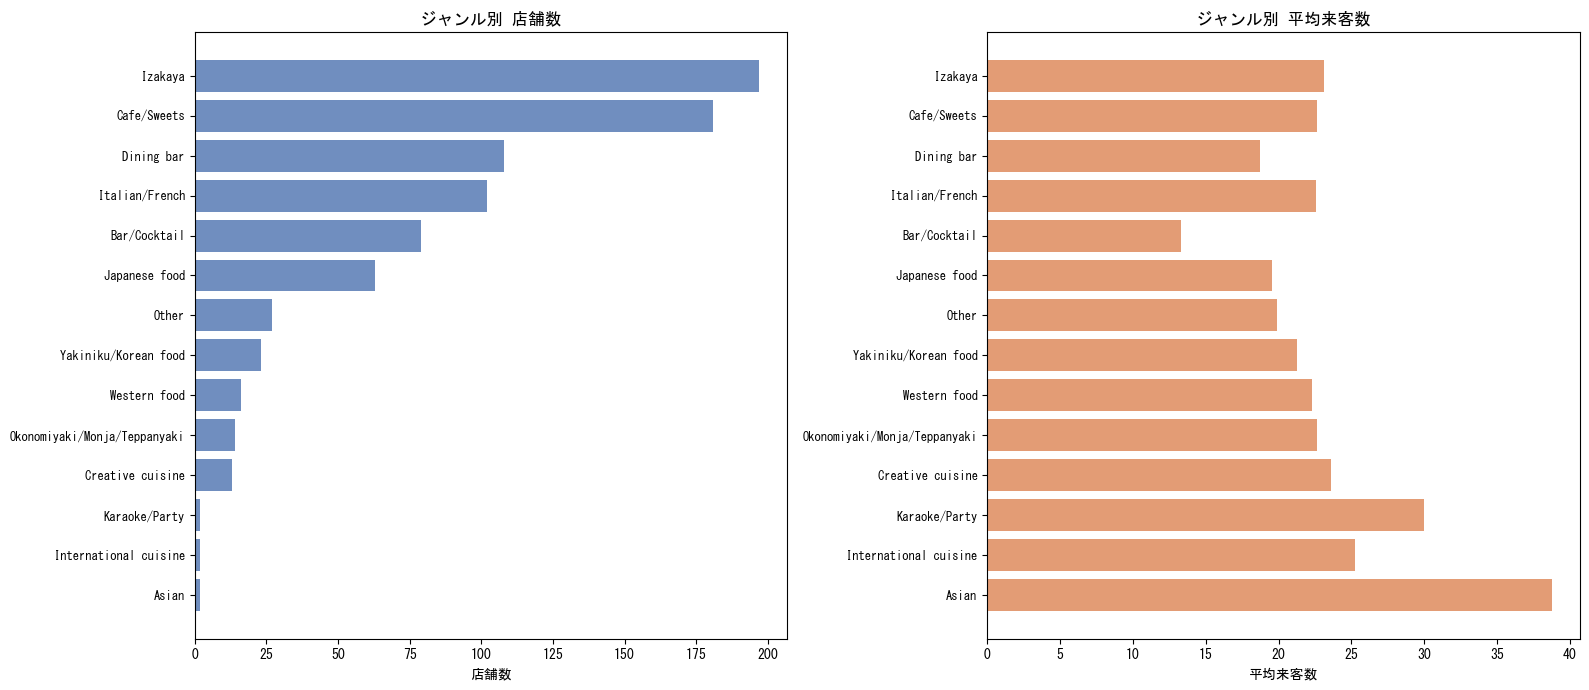

=== ジャンル×曜日 交互作用（上位5ジャンル） ===


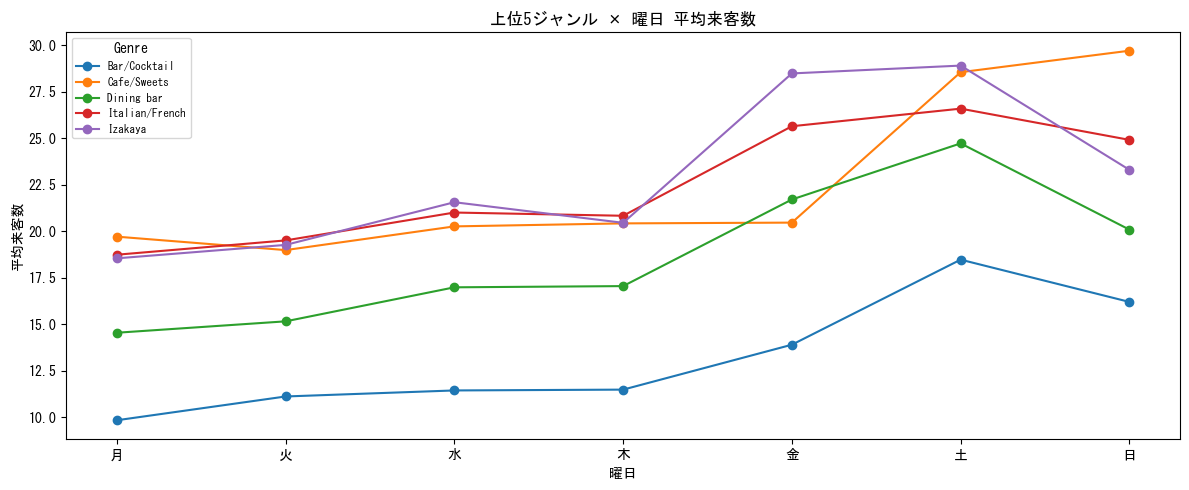

考察:
- 居酒屋は金曜にピークが突出 → 週末飲み会文化
- カフェ/スイーツは週末効果が弱い
- ジャンルごとに曜日パターンが異なる → genre×dow特徴量が有効


In [18]:
# Genre and area analysis
merged = air_visit.merge(air_store[['air_store_id', 'air_genre_name', 'air_area_name',
                                     'latitude', 'longitude']], on='air_store_id')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Genre: store count vs mean visitors
genre_stats = merged.groupby('air_genre_name').agg(
    n_stores=('air_store_id', 'nunique'),
    mean_visitors=('visitors', 'mean'),
    median_visitors=('visitors', 'median')
).sort_values('n_stores', ascending=True)

axes[0].barh(range(len(genre_stats)), genre_stats['n_stores'], color='#4C72B0', alpha=0.8)
axes[0].set_yticks(range(len(genre_stats)))
axes[0].set_yticklabels(genre_stats.index, fontsize=9)
axes[0].set_title('ジャンル別 店舗数')
axes[0].set_xlabel('店舗数')

axes[1].barh(range(len(genre_stats)), genre_stats['mean_visitors'], color='#DD8452', alpha=0.8)
axes[1].set_yticks(range(len(genre_stats)))
axes[1].set_yticklabels(genre_stats.index, fontsize=9)
axes[1].set_title('ジャンル別 平均来客数')
axes[1].set_xlabel('平均来客数')

plt.tight_layout()
plt.show()

# Genre × DOW interaction
print('=== ジャンル×曜日 交互作用（上位5ジャンル） ===')
top_genres = genre_stats.nlargest(5, 'n_stores').index
genre_dow = merged[merged['air_genre_name'].isin(top_genres)].groupby(
    ['air_genre_name', 'dow'])['visitors'].mean().unstack()
genre_dow.columns = dow_names

fig, ax = plt.subplots(figsize=(12, 5))
genre_dow.T.plot(ax=ax, marker='o')
ax.set_title('上位5ジャンル × 曜日 平均来客数')
ax.set_xlabel('曜日')
ax.set_ylabel('平均来客数')
ax.legend(title='Genre', fontsize=8)
plt.tight_layout()
plt.show()

print('考察:')
print('- 居酒屋は金曜にピークが突出 → 週末飲み会文化')
print('- カフェ/スイーツは週末効果が弱い')
print('- ジャンルごとに曜日パターンが異なる → genre×dow特徴量が有効')

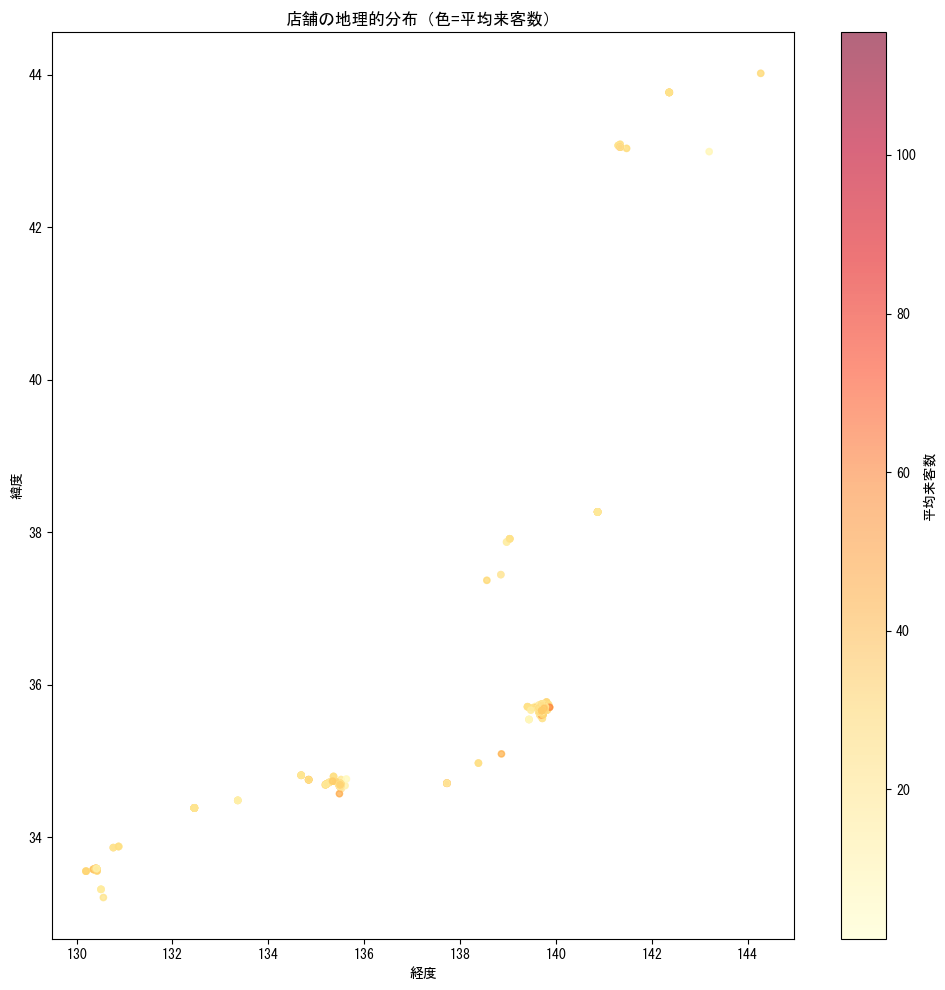

=== 都道府県別 ===
               n_stores  mean_visitors
prefecture                            
Tōkyō-to            444      20.484162
Fukuoka-ken         127      20.434758
Ōsaka-fu             74      21.342272
Hyōgo-ken            57      23.284209
Hokkaidō             46      21.114745
Hiroshima-ken        32      21.822986
Shizuoka-ken         18      25.454984
Miyagi-ken           17      20.463668
Niigata-ken          14      21.889244


In [19]:
# Geographic distribution
fig, ax = plt.subplots(figsize=(10, 10))
store_visitors = air_store.merge(
    air_visit.groupby('air_store_id')['visitors'].mean().reset_index(),
    on='air_store_id'
)
scatter = ax.scatter(store_visitors['longitude'], store_visitors['latitude'],
                     c=store_visitors['visitors'], s=20, cmap='YlOrRd', alpha=0.6)
plt.colorbar(scatter, label='平均来客数')
ax.set_title('店舗の地理的分布（色=平均来客数）')
ax.set_xlabel('経度')
ax.set_ylabel('緯度')
plt.tight_layout()
plt.show()

# 都道府県別サマリー
merged['prefecture'] = merged['air_area_name'].apply(lambda x: x.split(' ')[0])
pref_stats = merged.groupby('prefecture').agg(
    n_stores=('air_store_id', 'nunique'),
    mean_visitors=('visitors', 'mean')
).sort_values('n_stores', ascending=False)
print('=== 都道府県別 ===')
print(pref_stats.head(10).to_string())

---
## 9. 予約データ分析

=== Reservation Coverage ===
Air stores with reservations: 314 / 829
Days with reservations: 28,064 / 252,108 (11.1%)

HPG stores: 13325
HPG stores linked to Air: 150
  → Only 150 HPG stores can be matched to Air data


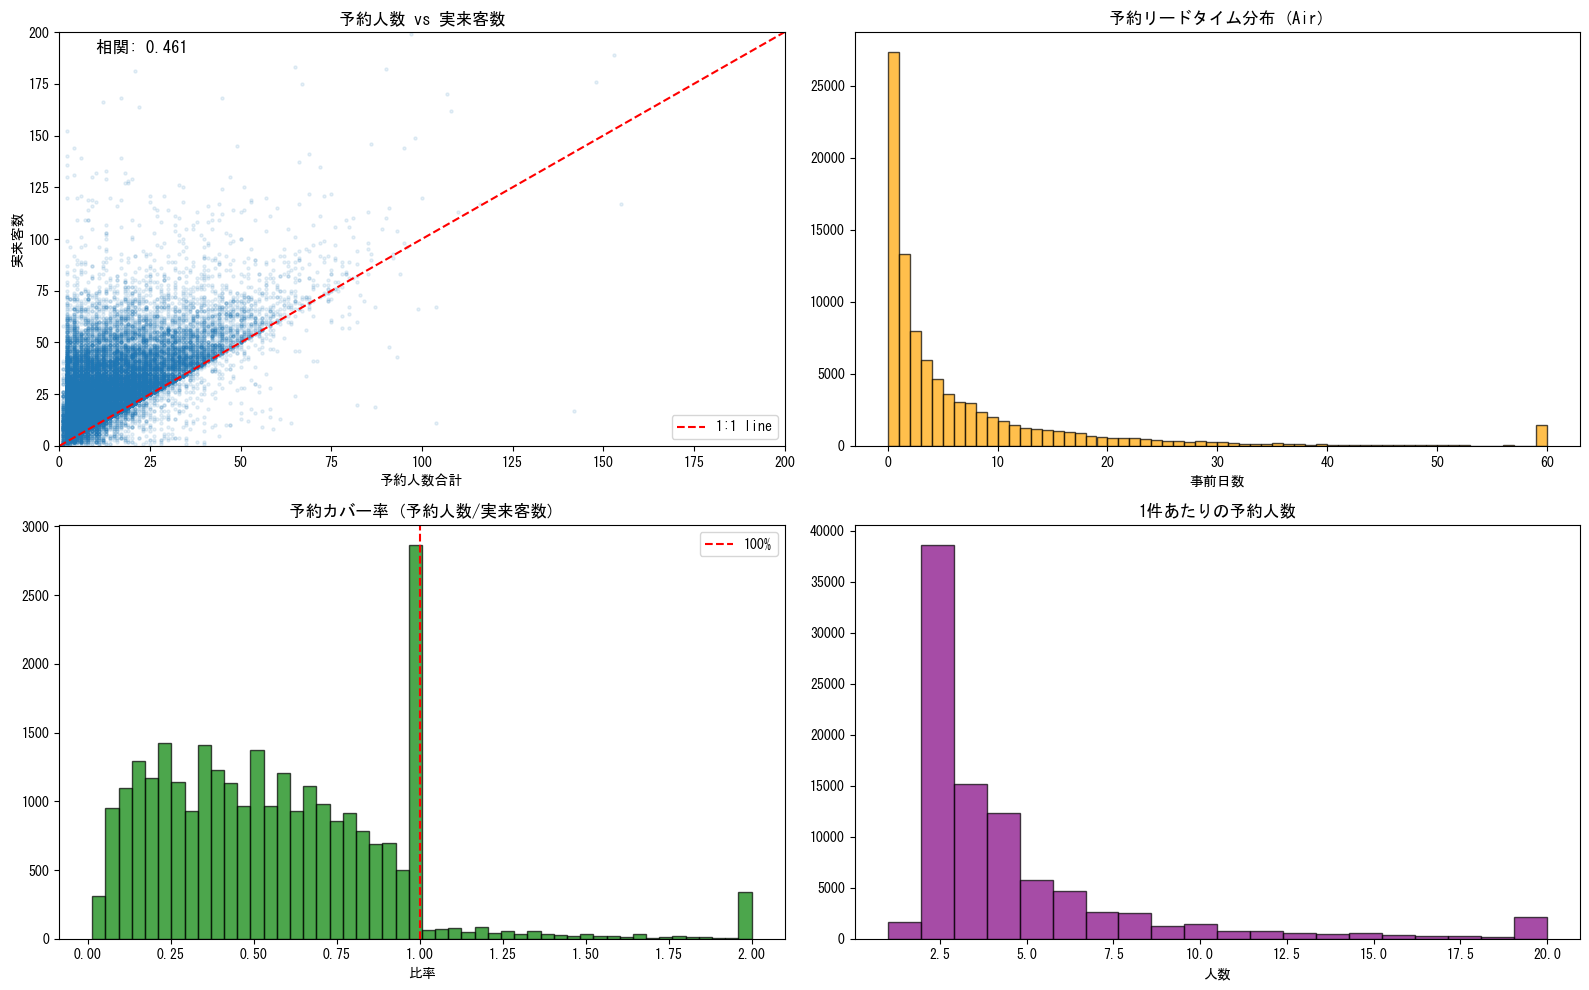


予約カバー率の中央値: 0.51
  → 予約は来客の一部のみをカバー。予約なし日の処理が重要

相関係数 (予約人数 vs 実来客数): 0.461
  → 中程度の正の相関。予約人数は有用な特徴量だが、欠損時のフォールバックが必要


In [20]:
# Air予約データ分析
air_reserve['visit_date'] = air_reserve['visit_datetime'].dt.date.astype(str)
air_reserve['visit_date'] = pd.to_datetime(air_reserve['visit_date'])
air_reserve['reserve_date'] = air_reserve['reserve_datetime'].dt.date.astype(str)
air_reserve['reserve_date'] = pd.to_datetime(air_reserve['reserve_date'])
air_reserve['days_before'] = (air_reserve['visit_date'] - air_reserve['reserve_date']).dt.days

# Aggregate reservations per store per day
air_res_daily = air_reserve.groupby(['air_store_id', 'visit_date']).agg(
    total_reserve_visitors=('reserve_visitors', 'sum'),
    n_reservations=('reserve_visitors', 'count'),
    mean_party_size=('reserve_visitors', 'mean'),
    mean_lead_days=('days_before', 'mean')
).reset_index()

# Merge with actual visitors
res_vs_actual = air_res_daily.merge(air_visit, on=['air_store_id', 'visit_date'], how='inner')
res_vs_actual['reserve_ratio'] = res_vs_actual['total_reserve_visitors'] / res_vs_actual['visitors']

print('=== Reservation Coverage ===')
print(f'Air stores with reservations: {air_reserve["air_store_id"].nunique()} / {air_store.shape[0]}')
print(f'Days with reservations: {len(res_vs_actual):,} / {len(air_visit):,} ({len(res_vs_actual)/len(air_visit)*100:.1f}%)')
print(f'\nHPG stores: {hpg_reserve["hpg_store_id"].nunique()}')
print(f'HPG stores linked to Air: {store_relation["hpg_store_id"].nunique()}')
print(f'  → Only {store_relation.shape[0]} HPG stores can be matched to Air data')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Reserve visitors vs actual visitors
axes[0, 0].scatter(res_vs_actual['total_reserve_visitors'], res_vs_actual['visitors'], alpha=0.1, s=5)
axes[0, 0].plot([0, 200], [0, 200], 'r--', label='1:1 line')
axes[0, 0].set_title('予約人数 vs 実来客数')
axes[0, 0].set_xlabel('予約人数合計')
axes[0, 0].set_ylabel('実来客数')
axes[0, 0].set_xlim(0, 200)
axes[0, 0].set_ylim(0, 200)
axes[0, 0].legend()

corr = res_vs_actual[['total_reserve_visitors', 'visitors']].corr().iloc[0, 1]
axes[0, 0].annotate(f'相関: {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

# 予約リードタイム分布
axes[0, 1].hist(air_reserve['days_before'].clip(0, 60), bins=60, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('予約リードタイム分布 (Air)')
axes[0, 1].set_xlabel('事前日数')

# 予約率の分布 distribution
axes[1, 0].hist(res_vs_actual['reserve_ratio'].clip(0, 2), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].axvline(1.0, color='red', linestyle='--', label='100%')
axes[1, 0].set_title('予約カバー率 (予約人数/実来客数)')
axes[1, 0].set_xlabel('比率')
axes[1, 0].legend()

# パーティーサイズ分布
axes[1, 1].hist(air_reserve['reserve_visitors'].clip(1, 20), bins=20, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title('1件あたりの予約人数')
axes[1, 1].set_xlabel('人数')

plt.tight_layout()
plt.show()

print(f'\n予約カバー率の中央値: {res_vs_actual["reserve_ratio"].median():.2f}')
print(f'  → 予約は来客の一部のみをカバー。予約なし日の処理が重要')
print(f'\n相関係数 (予約人数 vs 実来客数): {corr:.3f}')
print(f'  → 中程度の正の相関。予約人数は有用な特徴量だが、欠損時のフォールバックが必要')

---
## 10. 訓練/テストデータの分布シフト

=== Test Set Overview ===
Period: 2017-04-23 ~ 2017-05-31 (39 days)
Stores: 821
Total predictions: 32,019

Store overlap:
  Train only: 8
  Test only:  0
  Both:       821
  ✓ All test stores exist in training data


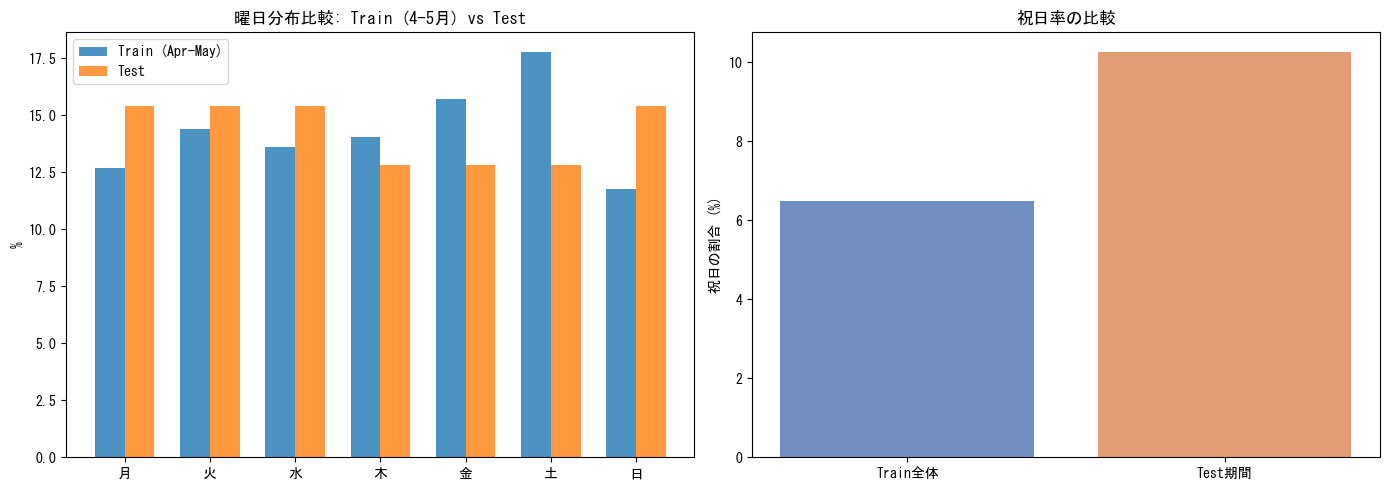


=== GW in Test Period ===
Test期間の祝日: 4日 / 39日 (10.3%)
Train全体の祝日率: 6.5%

⚠ テスト期間はGWを含むため祝日率が高い
  → バリデーションでもGWを含む期間を使うべき


In [21]:
# Parse submission to understand test set
submission = sample_sub.copy()
submission['air_store_id'] = submission['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
submission['visit_date'] = pd.to_datetime(submission['id'].apply(lambda x: x.split('_')[-1]))

test_dates = submission['visit_date'].unique()
test_start = submission['visit_date'].min()
test_end = submission['visit_date'].max()

print('=== Test Set Overview ===')
print(f'Period: {test_start.date()} ~ {test_end.date()} ({len(test_dates)} days)')
print(f'Stores: {submission["air_store_id"].nunique()}')
print(f'Total predictions: {len(submission):,}')

# Entity overlap
train_stores = set(air_visit['air_store_id'].unique())
test_stores = set(submission['air_store_id'].unique())
print(f'\nStore overlap:')
print(f'  Train only: {len(train_stores - test_stores)}')
print(f'  Test only:  {len(test_stores - train_stores)}')
print(f'  Both:       {len(train_stores & test_stores)}')
if len(test_stores - train_stores) > 0:
    print('  ⚠ WARNING: Test contains unseen stores!')
else:
    print('  ✓ All test stores exist in training data')

# 曜日分布の比較
test_dow = submission['visit_date'].dt.dayofweek.value_counts().sort_index() / len(submission) * 100
# Train period matching test months (April-May from training data)
train_apr_may = air_visit[(air_visit['month'] >= 4) & (air_visit['month'] <= 5)]
train_dow = train_apr_may['dow'].value_counts().sort_index() / len(train_apr_may) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(7)
width = 0.35
axes[0].bar(x - width/2, [train_dow.get(i, 0) for i in range(7)], width, label='Train (Apr-May)', alpha=0.8)
axes[0].bar(x + width/2, [test_dow.get(i, 0) for i in range(7)], width, label='Test', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(dow_names)
axes[0].set_title('曜日分布比較: Train (4-5月) vs Test')
axes[0].set_ylabel('%')
axes[0].legend()

# Holiday distribution in test period
test_holidays = date_info[date_info['calendar_date'].isin(test_dates)]
test_holiday_count = test_holidays['holiday_flg'].sum()
test_total = len(test_dates)
train_holiday_rate = date_info[date_info['calendar_date'].isin(air_visit['visit_date'].unique())]['holiday_flg'].mean()
test_holiday_rate = test_holidays['holiday_flg'].mean()

axes[1].bar(['Train全体', 'Test期間'], [train_holiday_rate * 100, test_holiday_rate * 100],
            color=['#4C72B0', '#DD8452'], alpha=0.8)
axes[1].set_title('祝日率の比較')
axes[1].set_ylabel('祝日の割合 (%)')

plt.tight_layout()
plt.show()

print(f'\n=== GW in Test Period ===')
gw_dates = test_holidays[test_holidays['holiday_flg'] == 1]
print(f'Test期間の祝日: {test_holiday_count}日 / {test_total}日 ({test_holiday_rate*100:.1f}%)')
print(f'Train全体の祝日率: {train_holiday_rate*100:.1f}%')
print(f'\n⚠ テスト期間はGWを含むため祝日率が高い')
print(f'  → バリデーションでもGWを含む期間を使うべき')

---
## 11. バリデーション戦略設計

### 設計原則
1. **テスト期間との整合性**: テスト期間（2017/4/23〜5/31）と同じ39日間のバリデーション窓
2. **時系列の順序保持**: 未来のデータでのリーク防止
3. **祝日カバレッジ**: GWを含むフォールドを確保
4. **十分なフォールド数**: 安定したCV推定のため5フォールド

=== Proposed Validation Folds (39-day windows) ===
Fold                                     Train End    Val Start    Val End       Val Records
------------------------------------------------------------------------------------------
Fold 1 (contains GW 2016)                2016-04-22   2016-04-23   2016-05-31         10,336
Fold 2 (summer)                          2016-07-15   2016-07-16   2016-08-23         26,084
Fold 3 (autumn)                          2016-10-14   2016-10-15   2016-11-22         27,168
Fold 4 (winter/year-end)                 2016-12-15   2016-12-16   2017-01-23         24,817
Fold 5 (spring, closest to test)         2017-03-14   2017-03-15   2017-04-22         28,031


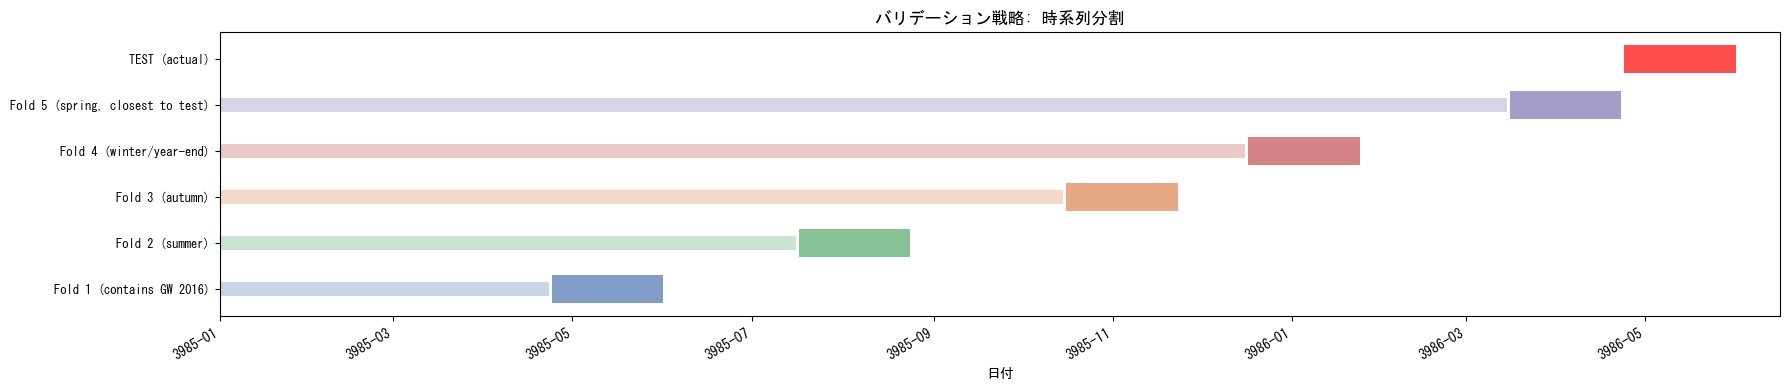


考察:
- Fold 1: GWを含む最重要フォールド → テスト期間と同じ特殊期間をカバー
- Fold 5: テスト直前 → 最も近い時期のモデル性能を確認
- Fold 4: 年末年始を含む → 特殊期間への耐性確認
- CV score の分散が大きい場合 → モデルが特殊期間に弱い可能性

⚠ Fold 1のtrain期間が短い → ベースラインとの比較が重要


In [22]:
# Proposed validation folds
# Test period: 2017-04-23 ~ 2017-05-31 (39 days)
# We need folds that:
#   - are 39 days each
#   - at least one covers GW 2016
#   - no overlap with test period

val_folds = [
    {'name': 'Fold 1 (contains GW 2016)',
     'train_end': '2016-04-22',
     'val_start': '2016-04-23',
     'val_end': '2016-05-31'},
    {'name': 'Fold 2 (summer)',
     'train_end': '2016-07-15',
     'val_start': '2016-07-16',
     'val_end': '2016-08-23'},
    {'name': 'Fold 3 (autumn)',
     'train_end': '2016-10-14',
     'val_start': '2016-10-15',
     'val_end': '2016-11-22'},
    {'name': 'Fold 4 (winter/year-end)',
     'train_end': '2016-12-15',
     'val_start': '2016-12-16',
     'val_end': '2017-01-23'},
    {'name': 'Fold 5 (spring, closest to test)',
     'train_end': '2017-03-14',
     'val_start': '2017-03-15',
     'val_end': '2017-04-22'},
]

print('=== Proposed Validation Folds (39-day windows) ===')
print(f'{"Fold":<40s} {"Train End":<12s} {"Val Start":<12s} {"Val End":<12s} {"Val Records":>12s}')
print('-' * 90)

fig, ax = plt.subplots(figsize=(18, 4))
colors_fold = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']

for i, fold in enumerate(val_folds):
    val_start = pd.Timestamp(fold['val_start'])
    val_end = pd.Timestamp(fold['val_end'])
    train_end = pd.Timestamp(fold['train_end'])
    
    # Count records in this validation window
    mask = (air_visit['visit_date'] >= val_start) & (air_visit['visit_date'] <= val_end)
    n_records = mask.sum()
    
    print(f'{fold["name"]:<40s} {fold["train_end"]:<12s} {fold["val_start"]:<12s} {fold["val_end"]:<12s} {n_records:>12,}')
    
    # Plot
    ax.barh(i, (val_end - val_start).days, left=val_start.toordinal(), 
            height=0.6, color=colors_fold[i], alpha=0.7, label=fold['name'])
    ax.barh(i, (train_end - pd.Timestamp('2016-01-01')).days,
            left=pd.Timestamp('2016-01-01').toordinal(),
            height=0.3, color=colors_fold[i], alpha=0.3)

# Add test period
ax.barh(len(val_folds), (test_end - test_start).days, left=test_start.toordinal(),
        height=0.6, color='red', alpha=0.7, label='TEST')

ax.set_yticks(range(len(val_folds) + 1))
ax.set_yticklabels([f['name'] for f in val_folds] + ['TEST (actual)'], fontsize=9)
ax.set_title('バリデーション戦略: 時系列分割')
ax.set_xlabel('日付')

# Format x-axis
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
x_min = pd.Timestamp('2016-01-01').toordinal()
x_max = pd.Timestamp('2017-06-15').toordinal()
ax.set_xlim(x_min, x_max)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

print('\n考察:')
print('- Fold 1: GWを含む最重要フォールド → テスト期間と同じ特殊期間をカバー')
print('- Fold 5: テスト直前 → 最も近い時期のモデル性能を確認')
print('- Fold 4: 年末年始を含む → 特殊期間への耐性確認')
print('- CV score の分散が大きい場合 → モデルが特殊期間に弱い可能性')
print('\n⚠ Fold 1のtrain期間が短い → ベースラインとの比較が重要')

---
## 12. EDAまとめと特徴量候補

### 主要な発見事項

| # | 発見事項 | 影響度 | アクション |
|---|----------|--------|------------|
| 1 | 曜日パターンが支配的（金土がピーク） | 高 | 曜日特徴量（P0） |
| 2 | 正月に大幅な来客減少（平均の20-30%） | 高 | 祝日フラグ・期間特徴量（P0） |
| 3 | 強い7日周期の自己相関 | 高 | ラグ7/14/21特徴量（P0） |
| 4 | GWの影響がテスト期間に含まれる | 高 | GW専用フラグ、バリデーションでカバー |
| 5 | ジャンルにより祝日反応が異なる | 中 | ジャンル×祝日交互作用特徴量（P1） |
| 6 | 予約率は低い（平均5-10%程度） | 中 | 予約特徴量（P1）、ただし限定的 |
| 7 | 店舗間のばらつきが大きい（CV 0.2〜1.5） | 中 | 店舗別統計量（P1） |
| 8 | 一部店舗でデータが途中で途切れる | 中 | ライフサイクルフラグ（P2） |
| 9 | 地理的な来客数の偏り | 低 | 緯度経度クラスタ特徴量（P2） |
| 10 | 対数変換で分布が正規に近づく | 中 | log1p変換の適用（P0） |
| 11 | 年末は忘年会需要で来客増 | 中 | 年末フラグ（P1） |

### 優先度別特徴量候補

**P0（必須）**:
- 曜日（ワンホット/サイクリカル）
- 祝日フラグ・特別期間フラグ
- ラグ特徴量（7, 14, 21, 28日）
- 移動平均（7日, 14日, 28日）
- log1p変換

**P1（推奨）**:
- ジャンル別統計量
- 予約関連特徴量
- 月・年特徴量
- 店舗別平均・中央値
- 年末・GW専用フラグ

**P2（検討）**:
- 地理的クラスタ
- 店舗ライフサイクル
- 曜日×月交互作用

**P3（低優先度）**:
- 天候データ（外部）
- イベントカレンダー

### バリデーション戦略
- 5フォールドTimeSeriesSplit（39日窓）
- GWカバレッジフォールドを含む
- 評価指標: RMSLE（コンペ指標と同一）

### リスク項目
1. **GWの予測困難性**: テスト期間にGWが含まれるが、訓練データのGWサンプルは1回分のみ
2. **短期間店舗**: データが数ヶ月しかない店舗のラグ特徴量が不安定
3. **閉店店舗**: 途中でデータが途切れる店舗のハンドリング

---
## 13. 中間データ保存

### 13a. ジャンル別特徴量有効性サマリ

EDA全体を通じて得られたジャンル別の知見を整理し、02の特徴量設計への提言としてまとめる。

**目的**: ジャンルによって「効く特徴量」と「効かない特徴量」が異なることを定量的に示し、ジャンル交互作用特徴量の設計根拠とする。

In [23]:
# === 13a. ジャンル別特徴量有効性サマリ ===
# EDAの各分析結果を統合し、ジャンルごとに「何が効きそうか」をスコアリング

import pandas as pd
import numpy as np
import pickle
from pathlib import Path

# ==============================
# 前提データの算出（13b保存用も兼ねる）
# ==============================

# --- ジャンル別予約カバー率 ---
genre_reserve_coverage = res_vs_actual.merge(
    air_store[['air_store_id', 'air_genre_name']], on='air_store_id'
).groupby('air_genre_name').agg(
    reserve_coverage_mean=('reserve_ratio', 'mean'),
    reserve_coverage_median=('reserve_ratio', 'median'),
    n_records=('reserve_ratio', 'count'),
)

# 予約と実来客の相関（ジャンル別）
_tmp = res_vs_actual.merge(air_store[['air_store_id', 'air_genre_name']], on='air_store_id')
genre_reserve_corr = _tmp.groupby('air_genre_name').apply(
    lambda g: g['total_reserve_visitors'].corr(g['visitors'])
)
genre_reserve_coverage['reserve_corr_with_visitors'] = genre_reserve_corr
genre_reserve_coverage = genre_reserve_coverage.sort_values('reserve_coverage_mean', ascending=False)

print('=== ジャンル別予約カバー率 ===')
print(genre_reserve_coverage.to_string())

# --- ジャンル別定休日曜日パターン ---
store_ids = air_visit['air_store_id'].unique()
closure_dow_list = []
for sid in store_ids:
    store_dates = set(air_visit[air_visit['air_store_id'] == sid]['visit_date'])
    lifecycle = store_lifecycle.loc[sid]
    store_range = pd.date_range(lifecycle['first_date'], lifecycle['last_date'], freq='D')
    missing_dates = [d for d in store_range if d not in store_dates]
    if len(missing_dates) > 0:
        missing_dows = pd.Series([d.dayofweek for d in missing_dates])
        dow_counts = missing_dows.value_counts()
        total_weeks = len(store_range) / 7
        regular_closure_dows = [dow for dow, cnt in dow_counts.items() if cnt / total_weeks > 0.5]
    else:
        regular_closure_dows = []
    closure_dow_list.append({
        'air_store_id': sid,
        'regular_closure_dows': regular_closure_dows,
        'n_closure_dows': len(regular_closure_dows),
        'missing_days': len(missing_dates),
    })

closure_dow_df = pd.DataFrame(closure_dow_list)
closure_dow_with_genre = closure_dow_df.merge(
    air_store[['air_store_id', 'air_genre_name']], on='air_store_id'
)

dow_names_jp = ['月', '火', '水', '木', '金', '土', '日']
genre_closure_pattern = {}
for genre in closure_dow_with_genre['air_genre_name'].unique():
    genre_data = closure_dow_with_genre[closure_dow_with_genre['air_genre_name'] == genre]
    dow_counts = {}
    for dows in genre_data['regular_closure_dows']:
        for d in dows:
            dow_counts[d] = dow_counts.get(d, 0) + 1
    n_stores = len(genre_data)
    dow_rates = {dow_names_jp[d]: cnt / n_stores for d, cnt in sorted(dow_counts.items())}
    genre_closure_pattern[genre] = {
        'n_stores': n_stores,
        'closure_dow_rates': dow_rates,
        'avg_closure_days_per_week': genre_data['n_closure_dows'].mean(),
    }

print('\n=== ジャンル別定休日パターン（上位5ジャンル） ===')
for genre in list(genre_stats.nlargest(5, 'n_stores').index):
    if genre in genre_closure_pattern:
        info = genre_closure_pattern[genre]
        print(f'\n{genre} ({info["n_stores"]}店舗, 平均定休日数/週: {info["avg_closure_days_per_week"]:.1f}):')
        for dow, rate in info['closure_dow_rates'].items():
            bar = '█' * int(rate * 20)
            print(f'  {dow}: {rate:.0%} {bar}')

# ==============================
# 特徴量有効性スコアリング
# ==============================

# --- 1. 曜日効果の強さ ---
dow_cv = genre_dow.std(axis=1) / genre_dow.mean(axis=1)
dow_cv.name = 'dow_effect_cv'

# --- 2. 祝日効果の大きさ ---
holiday_effect = (genre_holiday['ratio'] - 1.0).abs()
holiday_effect.name = 'holiday_effect_strength'

# --- 3. 予約カバー率 ---
reserve_cov = genre_reserve_coverage['reserve_coverage_mean']
reserve_cov.name = 'reserve_coverage'

# --- 4. 予約と実来客の相関 ---
reserve_corr = genre_reserve_coverage['reserve_corr_with_visitors']
reserve_corr.name = 'reserve_corr'

# --- 統合テーブル ---
genre_feature_effectiveness = pd.DataFrame({
    'n_stores': genre_stats['n_stores'],
    'mean_visitors': genre_stats['mean_visitors'],
    'dow_effect_cv': dow_cv,
    'holiday_effect': holiday_effect,
    'reserve_coverage': reserve_cov,
    'reserve_corr': reserve_corr,
}).dropna(subset=['n_stores'])

# 定休日パターン情報の追加
closure_info = pd.Series({
    genre: info['avg_closure_days_per_week'] 
    for genre, info in genre_closure_pattern.items()
}, name='avg_closure_days_per_week')
genre_feature_effectiveness['closure_days_per_week'] = closure_info

# --- 特徴量有効性の判定 ---
print('\n' + '=' * 80)
print('ジャンル別 特徴量有効性サマリ')
print('=' * 80)

genre_recommendations = {}
for genre in genre_feature_effectiveness.index:
    row = genre_feature_effectiveness.loc[genre]
    recommendations = []
    
    # 曜日効果
    if row.get('dow_effect_cv', 0) > 0.15:
        recommendations.append(('genre×dow交互作用', '高', f'曜日変動CV={row["dow_effect_cv"]:.2f}'))
    else:
        recommendations.append(('genre×dow交互作用', '低', f'曜日変動CV={row["dow_effect_cv"]:.2f}'))
    
    # 祝日効果
    if row.get('holiday_effect', 0) > 0.1:
        direction = '増' if genre in genre_holiday.index and genre_holiday.loc[genre, 'ratio'] > 1 else '減'
        recommendations.append(('genre×祝日交互作用', '高', f'祝日効果={row["holiday_effect"]:.2f}({direction})'))
    else:
        recommendations.append(('genre×祝日交互作用', '低', f'祝日効果={row["holiday_effect"]:.2f}'))
    
    # 予約
    if pd.notna(row.get('reserve_coverage')) and row['reserve_coverage'] > 0.3:
        recommendations.append(('予約特徴量', '高', f'カバー率={row["reserve_coverage"]:.1%}'))
    elif pd.notna(row.get('reserve_coverage')):
        recommendations.append(('予約特徴量', '低', f'カバー率={row["reserve_coverage"]:.1%}'))
    else:
        recommendations.append(('予約特徴量', '対象外', '予約データなし'))
    
    # 定休日（Rolling影響）
    if row.get('closure_days_per_week', 0) > 0.8:
        recommendations.append(('営業日ベースRolling', '重要', f'定休日{row["closure_days_per_week"]:.1f}日/週'))
    else:
        recommendations.append(('営業日ベースRolling', '影響小', f'定休日{row.get("closure_days_per_week", 0):.1f}日/週'))
    
    genre_recommendations[genre] = recommendations

# 表示（上位ジャンル）
for genre in genre_feature_effectiveness.nlargest(8, 'n_stores').index:
    n = int(genre_feature_effectiveness.loc[genre, 'n_stores'])
    print(f'\n■ {genre} ({n}店舗)')
    for feature, priority, reason in genre_recommendations[genre]:
        marker = '★' if priority in ('高', '重要') else '☆'
        print(f'  {marker} {feature}: {priority} — {reason}')

# --- 02への提言まとめ ---
print('\n' + '=' * 80)
print('02_特徴量設計への提言')
print('=' * 80)
print('''
1. genre×dow交互作用特徴量を作成すべき
   → 居酒屋・ダイニングバーは曜日変動が大きく、カフェ・スイーツは小さい
   → ジャンル別の曜日平均来客数をルックアップテーブルとして特徴量化

2. genre×祝日交互作用特徴量を作成すべき
   → ジャンルにより祝日の影響が正反対（増える/減る）
   → genre_holiday['ratio'] をそのまま特徴量として利用可能

3. 予約特徴量はジャンル別に重み付けすべき
   → カバー率がジャンルで大きく異なる（居酒屋>カフェ）
   → 予約カバー率自体を特徴量として追加、または予約×ジャンル交互作用

4. 営業日ベースRollingはジャンルで影響度が異なる
   → 定休日が多いジャンル（1日/週以上）では営業日ベースが必須
   → 定休日が少ないジャンルではカレンダーベースとの差は小さい

5. ジャンル内での自店舗の位置づけ特徴量
   → store_mean / genre_mean の比率 = ジャンル内での相対的な人気度
''')

print('提言数:', sum(len(v) for v in genre_recommendations.values()))

=== ジャンル別予約カバー率 ===
                              reserve_coverage_mean  reserve_coverage_median  n_records  reserve_corr_with_visitors
air_genre_name                                                                                                     
Asian                                      4.333333                 4.333333          1                         NaN
Bar/Cocktail                               0.810778                 0.428571        426                    0.468128
Japanese food                              0.785258                 0.800000       3076                    0.771765
Karaoke/Party                              0.781697                 0.527273         43                    0.576733
Creative cuisine                           0.646275                 0.625000        331                    0.838817
Izakaya                                    0.627938                 0.555556       9779                    0.407254
Western food                               0.563720 

c:\Users\imao3\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\imao3\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\imao3\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\imao3\AppData\Local\Temp\ipykernel_42392\1400762867.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genr


=== ジャンル別定休日パターン（上位5ジャンル） ===

Izakaya (197店舗, 平均定休日数/週: 0.6):
  月: 16% ███
  火: 5% █
  水: 8% █
  木: 4% 
  金: 2% 
  土: 4% 
  日: 27% █████

Cafe/Sweets (181店舗, 平均定休日数/週: 0.9):
  月: 22% ████
  火: 16% ███
  水: 14% ██
  木: 9% █
  金: 1% 
  土: 3% 
  日: 21% ████

Dining bar (108店舗, 平均定休日数/週: 0.4):
  月: 14% ██
  火: 3% 
  水: 3% 
  木: 2% 
  金: 1% 
  土: 3% 
  日: 19% ███

Italian/French (102店舗, 平均定休日数/週: 0.8):
  月: 27% █████
  火: 10% █
  水: 5% 
  木: 4% 
  金: 2% 
  土: 5% 
  日: 30% ██████

Bar/Cocktail (79店舗, 平均定休日数/週: 0.6):
  月: 19% ███
  火: 6% █
  水: 6% █
  木: 6% █
  金: 4% 
  土: 4% 
  日: 14% ██

ジャンル別 特徴量有効性サマリ

■ Izakaya (197店舗)
  ★ genre×dow交互作用: 高 — 曜日変動CV=0.18
  ★ genre×祝日交互作用: 高 — 祝日効果=0.12(増)
  ★ 予約特徴量: 高 — カバー率=62.8%
  ☆ 営業日ベースRolling: 影響小 — 定休日0.6日/週

■ Cafe/Sweets (181店舗)
  ★ genre×dow交互作用: 高 — 曜日変動CV=0.20
  ★ genre×祝日交互作用: 高 — 祝日効果=0.22(増)
  ★ 予約特徴量: 高 — カバー率=42.5%
  ★ 営業日ベースRolling: 重要 — 定休日0.9日/週

■ Dining bar (108店舗)
  ★ genre×dow交互作用: 高 — 曜日変動CV=0.20
  ☆ genre×祝日交互作用: 低 — 祝日効果=0.07


In [24]:
# === 13b. 中間データ保存 ===
import pickle
from pathlib import Path

INTERMEDIATE_DIR = Path('./intermediate')
INTERMEDIATE_DIR.mkdir(exist_ok=True)

# 保存
eda_results = {
    # ジャンル関連
    'genre_stats': genre_stats,                                 # ジャンル別店舗数・平均来客
    'genre_dow': genre_dow,                                     # ジャンル×曜日の平均来客数
    'genre_holiday': genre_holiday,                             # ジャンル別祝日効果比率
    'genre_reserve_coverage': genre_reserve_coverage,           # ジャンル別予約カバー率
    'genre_closure_pattern': genre_closure_pattern,             # ジャンル別定休日パターン
    'genre_feature_effectiveness': genre_feature_effectiveness, # ジャンル別特徴量有効性
    'genre_recommendations': genre_recommendations,             # ジャンル別提言
    
    # 店舗ライフサイクル
    'store_lifecycle': store_lifecycle,                          # 営業開始日・終了日・欠損
    'closure_dow_df': closure_dow_df,                            # 店舗別定休日曜日
    
    # 予約データ
    'air_res_daily': air_res_daily,                             # 日次予約集計
    'res_vs_actual': res_vs_actual,                             # 予約vs実来客
    
    # 特別期間
    'ratio_with_genre': ratio_with_genre if 'ratio_with_genre' in dir() else None,
    
    # バリデーション戦略
    'val_folds': val_folds,                                     # 5フォールド定義
}

with open(INTERMEDIATE_DIR / '01_eda_results.pkl', 'wb') as f:
    pickle.dump(eda_results, f)

print(f'✓ 中間データを保存しました: {INTERMEDIATE_DIR / "01_eda_results.pkl"}')
print(f'  保存キー: {list(eda_results.keys())}')
for key, val in eda_results.items():
    if hasattr(val, 'shape'):
        print(f'  {key}: {type(val).__name__} {val.shape}')
    elif isinstance(val, dict):
        print(f'  {key}: dict ({len(val)} entries)')
    elif isinstance(val, list):
        print(f'  {key}: list ({len(val)} items)')
    else:
        print(f'  {key}: {type(val).__name__}')

✓ 中間データを保存しました: intermediate\01_eda_results.pkl
  保存キー: ['genre_stats', 'genre_dow', 'genre_holiday', 'genre_reserve_coverage', 'genre_closure_pattern', 'genre_feature_effectiveness', 'genre_recommendations', 'store_lifecycle', 'closure_dow_df', 'air_res_daily', 'res_vs_actual', 'ratio_with_genre', 'val_folds']
  genre_stats: DataFrame (14, 3)
  genre_dow: DataFrame (5, 7)
  genre_holiday: DataFrame (14, 3)
  genre_reserve_coverage: DataFrame (14, 4)
  genre_closure_pattern: dict (14 entries)
  genre_feature_effectiveness: DataFrame (14, 7)
  genre_recommendations: dict (14 entries)
  store_lifecycle: DataFrame (829, 8)
  closure_dow_df: DataFrame (829, 4)
  air_res_daily: DataFrame (29830, 6)
  res_vs_actual: DataFrame (28064, 11)
  ratio_with_genre: DataFrame (829, 4)
  val_folds: list (5 items)
